In [3]:
%pip install sinter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import stim
import pymatching
import numpy as np
import sinter
from typing import List
import matplotlib.pyplot as plt

In [2]:
import sys
import os
# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))

In [3]:
from src.utils.qccd_nodes import *
from src.utils.qccd_operations import *
from src.utils.qccd_operations_on_qubits import *
from src.utils.qccd_arch import *
from src.compiler.qccd_parallelisation import *
from src.compiler.qccd_qubits_to_ions import *
from src.compiler.qccd_ion_routing import *
from src.compiler.qccd_alt_ion_routing import *
from src.compiler.qccd_WISE_ion_route import *
from src.compiler.qccd_color_qubits_to_ions import *
from src.simulator.qccd_circuit import QCCDCircuit

In [4]:
NDE_LZ = 10
NDE_JZ = 20
NSE_Z = 10

def populate_results(results, label, parallelOpsMap, allOps, instructions, logicalErrors, physicalZErrors, physicalXErrors, capacity, distance):
    results["Capacity"] = capacity
    results["Distance"] = distance
    results["ElapsedTime"][label] = max(parallelOpsMap.keys())
    results["Operations"][label] = len(allOps)
    results["MeanConcurrency"][label] = np.mean([len(op.operations) for op in parallelOpsMap.values()])
    results["QubitOperations"][label] = len(instructions)
    results["LogicalErrorRates"][label] = logicalErrors
    results["PhysicalZErrorRates"][label] = physicalZErrors
    results["PhysicalXErrorRates"][label] = physicalXErrors

def simulate_and_collect_errors(circuit, allOps, gate_improvements, num_shots):
    logicalErrors = []
    physicalZErrors = []
    physicalXErrors = []
    
    for gate_improvement in gate_improvements:
        logicalError, physicalXError, physicalZError = circuit.simulate(allOps, num_shots=num_shots, error_scaling=gate_improvement)
        logicalErrors.append(logicalError)
        physicalZErrors.append(physicalZError)
        physicalXErrors.append(physicalXError)
    return logicalErrors, physicalZErrors, physicalXErrors
def calculate_electrodes_and_dacs(allOps, capacity, nqubitsNeeded, arch_type):
    if arch_type == 'wise':
        Njz = np.ceil(nqubitsNeeded / capacity)
        Nlz = nqubitsNeeded - Njz
    else:
        trapSet = set()
        junctionSet = set()
        for op in allOps:
            for c in op.involvedComponents:
                if isinstance(c, Trap):
                    trapSet.add(c)
                elif isinstance(c, Junction):
                    junctionSet.add(c)
        Njz = len(junctionSet)
        Nlz = len(trapSet)*capacity
    Nde = NDE_LZ*Nlz + NDE_JZ*Njz
    Nse = NSE_Z*(Njz + Nlz)
    Num_electrodes = Nde + Nse
    if arch_type == 'wise':
        Num_DACs = int(min(100, Nde) + np.ceil(Nse/100))
    else:
        Num_DACs = Num_electrodes
    return Num_electrodes, Num_DACs
    
def get_parallelopsmap(distance, rounds, tesselation, basis, capacity,cluster_merge_strategy='bounded', cluster_merge_threshold=2.5, placement_strategy="hill_climb"):
    circuit = QCCDCircuit.generate_color_code(distance, rounds=rounds, tesselation=tesselation, basis=basis)
    if tesselation == (6,6,6):
        nqubitsNeeded = (9*distance**2 -1)//8
        nqubitsNeeded = len(circuit.dataQubitsIdxs) + len(circuit.measureQubitsIdxs)
    elif tesselation == (4,8,8):
        nqubitsNeeded = (3*distance**2 +6*distance -5)//4
    
    #for dual ancilla (6.6.6) circuits
    #nqubitsNeeded = 3*(distance**2 - 1)//4 + (3*distance**2 + 1)//4
    #nrowsNeeded = int(np.sqrt(nqubitsNeeded))+2
    """
    #linear 
    trapsrequired = int(np.ceil(nqubitsNeeded/(capacity-1))) * 2

    arch, (instructions, _) = circuit.processColorCircuitLinearGrid(
        trapCapacity=capacity,
        traps = trapsrequired,
        dataQubitsIdxs=circuit.dataQubitsIdxs,
        measureQubitsIdxs=circuit.measureQubitsIdxs,
        cluster_merge_strategy=cluster_merge_strategy,
        cluster_merge_threshold=cluster_merge_threshold,
    )
    
    """
    """
    #switch
    trapsrequired = int(np.ceil(nqubitsNeeded/(capacity-1))) * 2
    
    arch, (instructions, _) = circuit.processColorCircuitNetworkedGrid(
        trapCapacity=capacity,
        traps = trapsrequired,
        dataQubitsIdxs=circuit.dataQubitsIdxs,
        measureQubitsIdxs=circuit.measureQubitsIdxs,
        cluster_merge_strategy=cluster_merge_strategy,
        cluster_merge_threshold=cluster_merge_threshold,
    )
    """
    nrowsNeeded = int(np.sqrt(nqubitsNeeded))+2

    arch, (instructions, _) = circuit.processColorCircuitAugmentedGrid(
        rows=nrowsNeeded,
        cols=nrowsNeeded,
        trapCapacity=capacity,
        dataQubitsIdxs=circuit.dataQubitsIdxs,
        measureQubitsIdxs=circuit.measureQubitsIdxs,
        cluster_merge_strategy=cluster_merge_strategy,
        cluster_merge_threshold=cluster_merge_threshold,
        placement_strategy=placement_strategy,
    )
    print(circuit._ionMapping)
    arch.refreshGraph()
    
    results = {"ElapsedTime": {}, "Operations": {}, "MeanConcurrency": {}, "QubitOperations": {}, "LogicalErrorRates": {}, "PhysicalZErrorRates": {}, "PhysicalXErrorRates": {}, "Electrodes": {}, "DACs": {}}
    
    label ="Forwarding"
    allOps, barriers = ionRouting(arch, instructions, capacity)
    
    parallelOpsMap = paralleliseOperationsWithBarriers(allOps, barriers)
    logicalErrors, physicalZErrors, physicalXErrors = simulate_and_collect_errors(circuit, allOps, [1.0], 1000000)

    #logger.info(f"Simulated {label} method with gate improvements for distance {distance}, capacity {capacity} and tesselation {tesselation}")
    
    
    for op in parallelOpsMap.values():
        op.calculateOperationTime()
        op.calculateFidelity()

    circuit.resetArch()
    arch.refreshGraph()

    populate_results(results, label, parallelOpsMap, allOps, instructions, logicalErrors, physicalZErrors, physicalXErrors, capacity, distance)


    Num_electrodes, Num_DACs = calculate_electrodes_and_dacs(allOps, capacity, nqubitsNeeded, 'augmented')
    results["DACs"][label] = Num_DACs
    results["Electrodes"][label] = Num_electrodes
    print(results)
    return arch,circuit, parallelOpsMap




In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib inline
from IPython.display import HTML, clear_output, display
import time

In [6]:
def update(frame, _arch):
    ax.clear()
    # Clear the output for dynamic display in Jupyter notebook
    clear_output(wait=True)
    if frame>0:
        op: ParallelOperation = parallelOps[frame-1]
        title = f"Operation {round(parallelOpsTimes[frame-1],6)}: {op.label}"
        _arch.display(fig, ax, title, operation=op, runOps=True, showLabels=False)
    else:
        _arch.display(fig, ax, showLabels=False)
    # time.sleep(3)
    return display(fig)

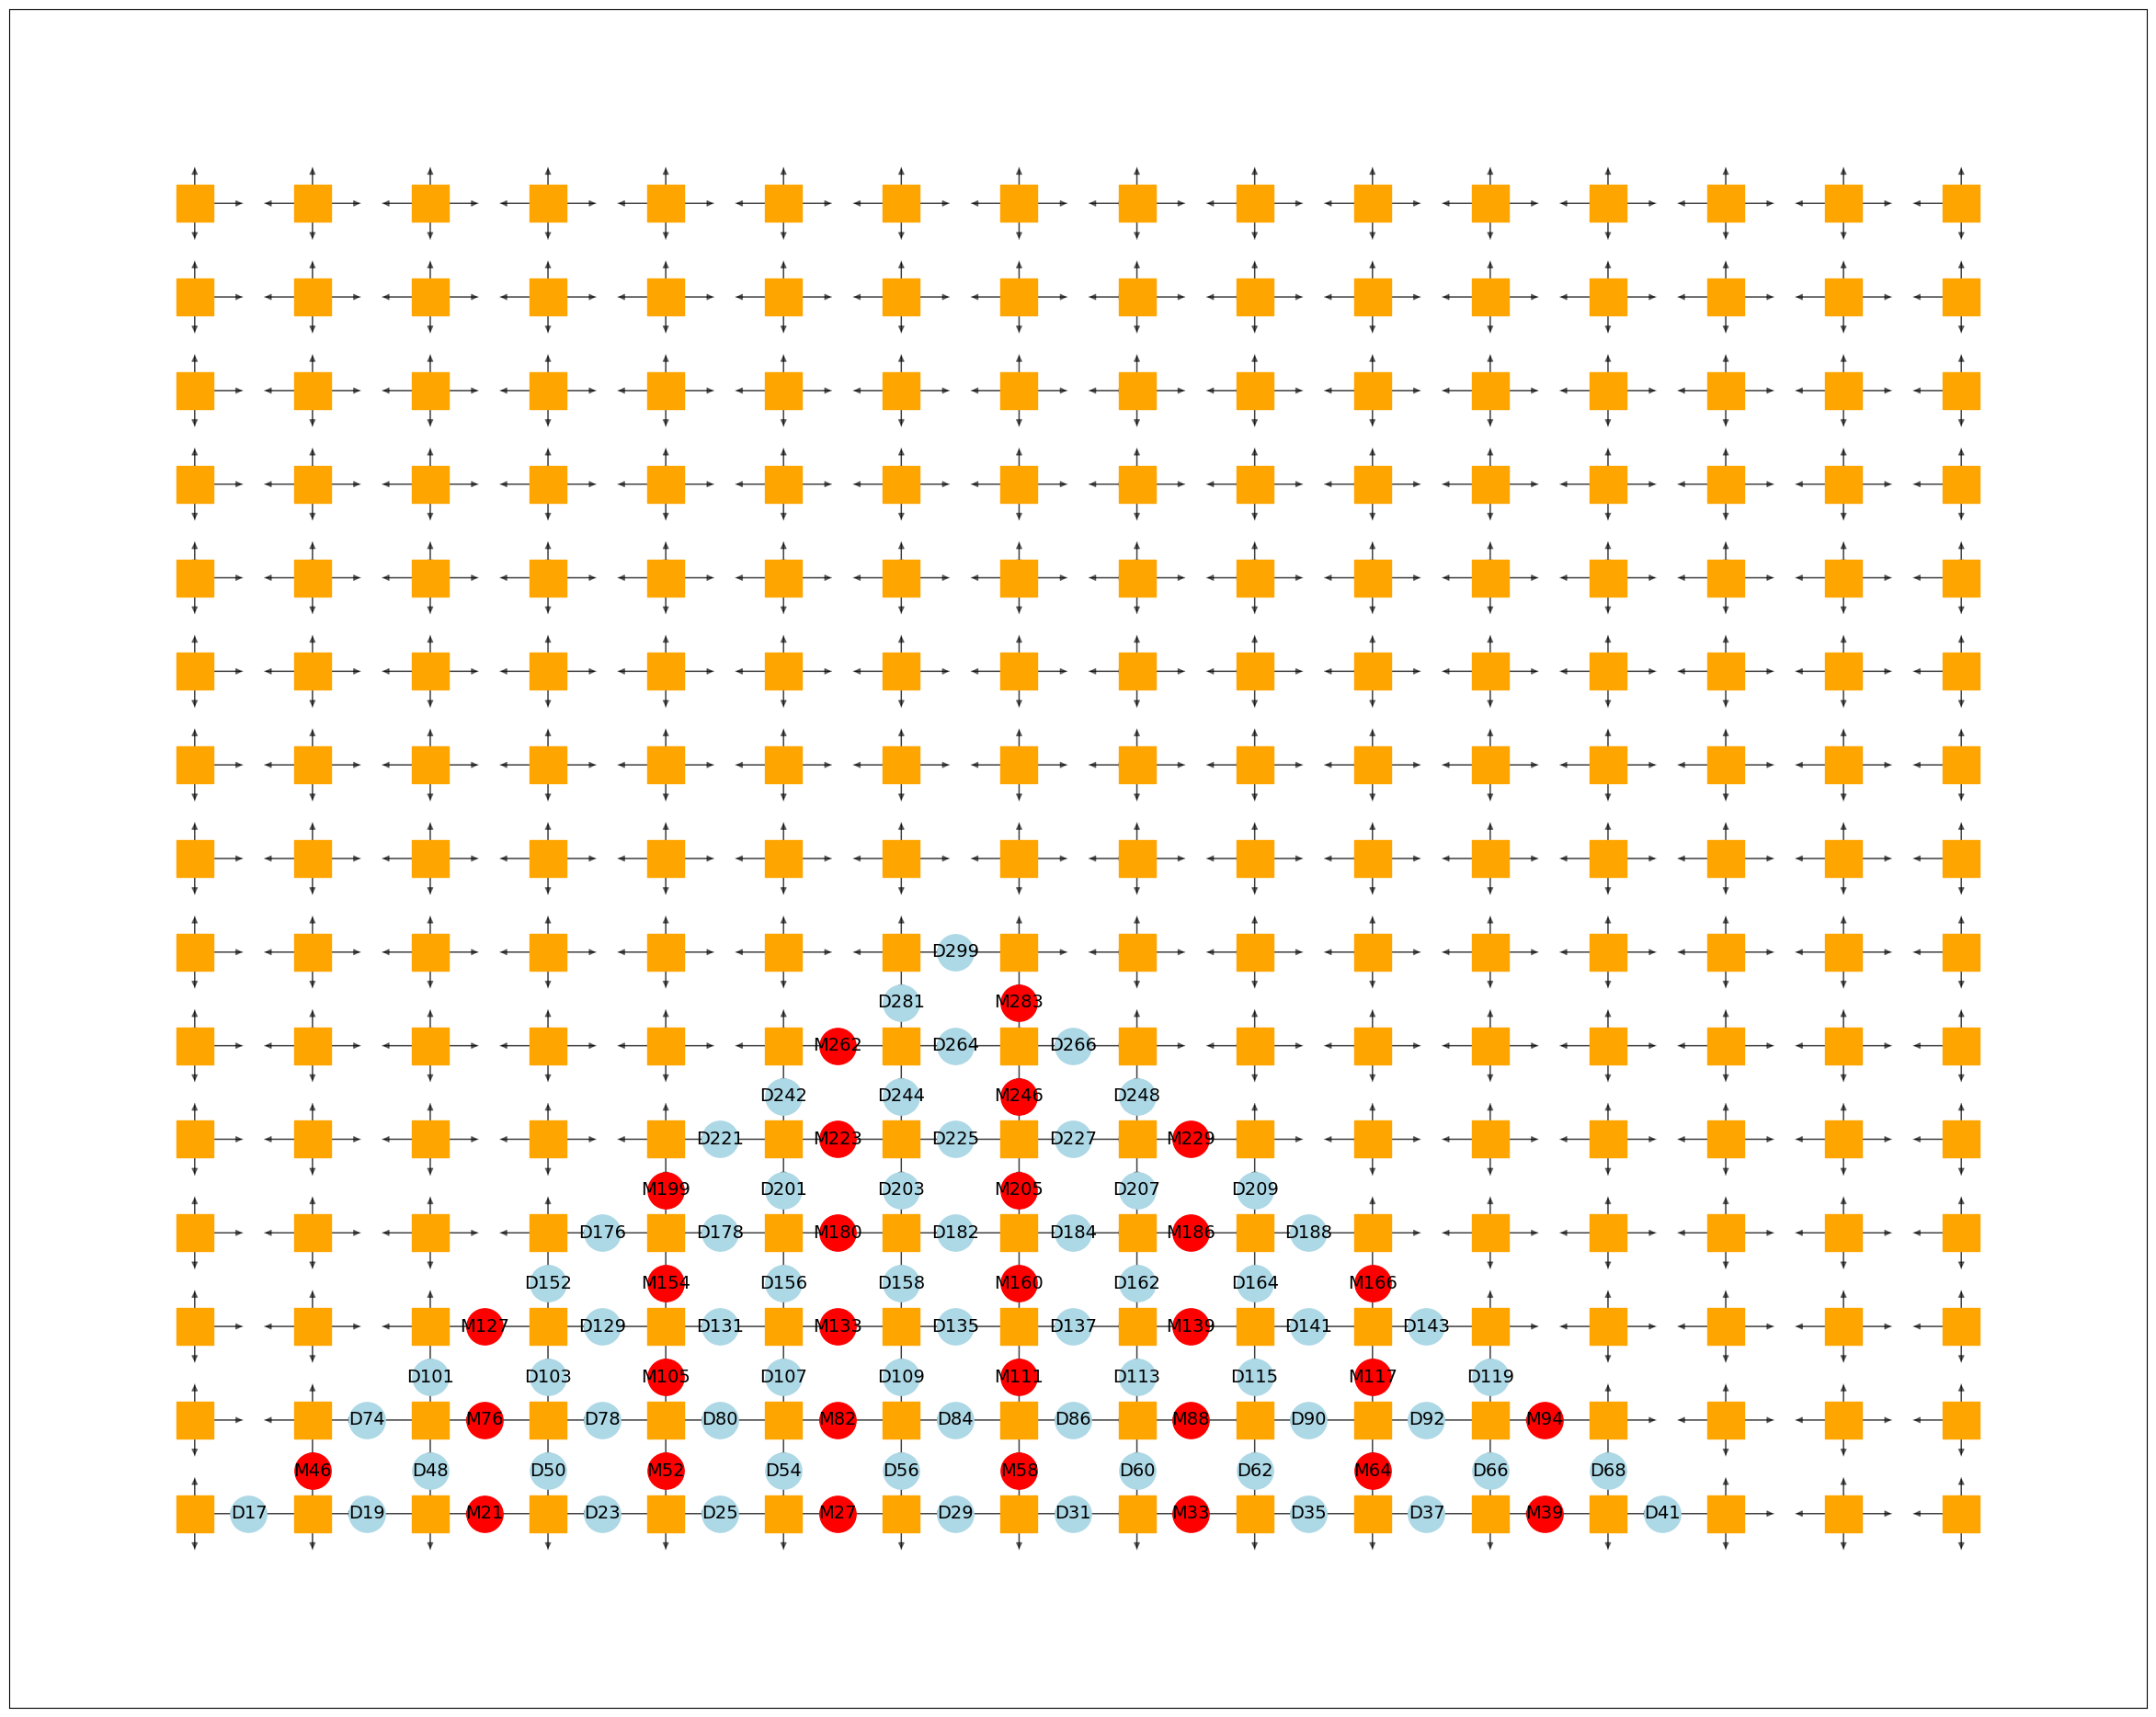

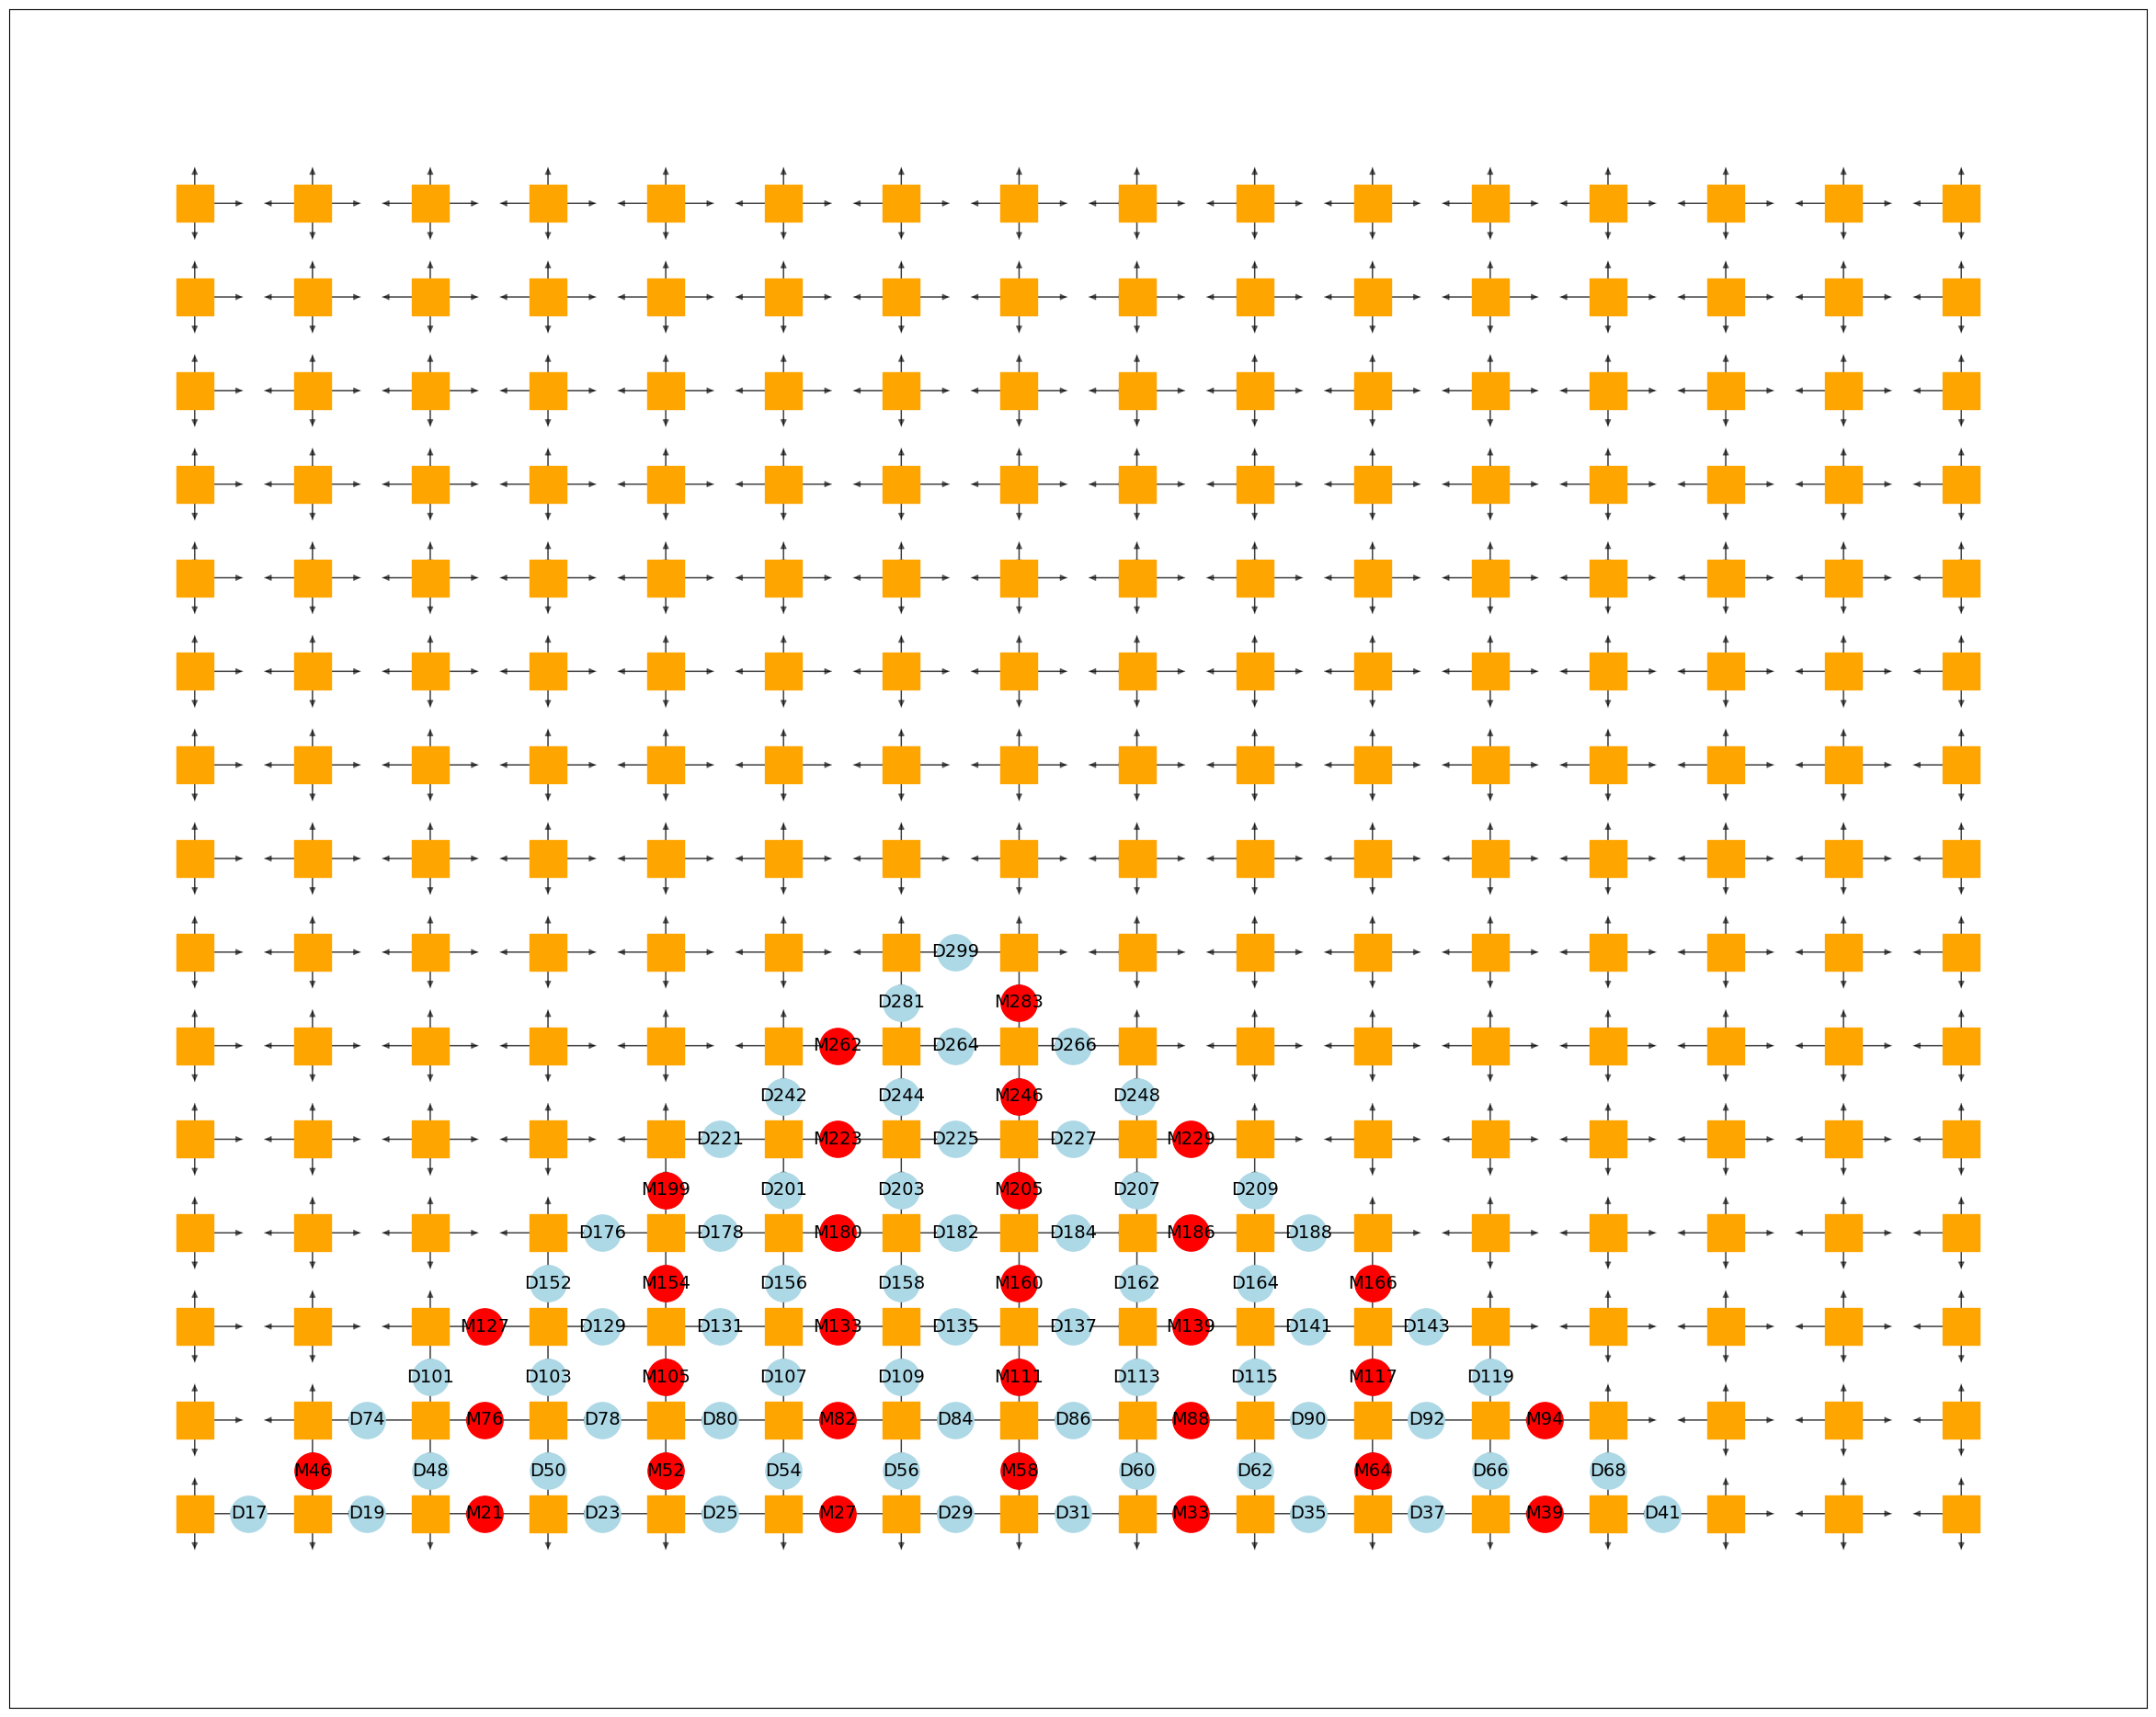

In [7]:
#halving mapping
arch,circuit, parallelOpsMap = get_parallelopsmap(9,1,(6,6,6),'Z',2,placement_strategy="direct_coordinate")
arch = circuit.resetArch()
arch.refreshGraph()
fig,ax=plt.subplots()
parallelOpsTimes = sorted(parallelOpsMap.keys())
parallelOps = [parallelOpsMap[t] for t in parallelOpsTimes]

print(parallelOpsTimes[-1])
#print(parallelOps)

#time.sleep(5)
ani = FuncAnimation(fig, lambda frame: update(frame, arch), frames=1, repeat=False)
HTML(ani.to_jshtml())

In [32]:
print({k:[op.label for op in v._operations] for k,v in parallelOpsMap.items()})

{0.0: ['QUBIT_RESET D6', 'QUBIT_RESET D8', 'QUBIT_RESET D12', 'QUBIT_RESET D14', 'QUBIT_RESET D20', 'QUBIT_RESET D22', 'QUBIT_RESET D24', 'QUBIT_RESET M10', 'QUBIT_RESET M16', 'QUBIT_RESET M18'], 5e-05: ['RX D6', 'RX D8', 'RX D12', 'RX D14', 'RX D20', 'RX D22', 'RX D24', 'QUBIT_RESET M10', 'QUBIT_RESET M16', 'QUBIT_RESET M18'], 0.0001: ['RY M10', 'RY M16', 'RY M18'], 0.000105: ['RX M10', 'RX M16', 'RX M18'], 0.00011: ['RY M10', 'RY M16', 'RY M18'], 0.000115: ['RX M10', 'RX M16', 'RX M18'], 0.00012: ['SPLIT M16'], 0.0002: ['MOVE M16'], 0.00020500000000000002: ['MERGE M16'], 0.00028500000000000004: ['GATE_SWAP M16 D14'], 0.0004050000000000001: ['SPLIT M16'], 0.0004850000000000001: ['MOVE M16'], 0.0004900000000000001: ['MERGE M16'], 0.0005700000000000001: ['TWO_QUBIT_MS_GATE M16 D12'], 0.0006100000000000001: ['SPLIT M16'], 0.0006900000000000001: ['MOVE M16'], 0.0006950000000000001: ['MERGE M16'], 0.0007750000000000001: ['GATE_SWAP M16 D14'], 0.0008950000000000001: ['SPLIT M16'], 0.0009750

In [12]:
def process_circuit(distance, capacity, gate_improvements, num_shots):
    

    #logger.info(f"Starting circuit generation for distance {distance} and capacity {capacity}")
  
    circuit = QCCDCircuit.generated(
        "surface_code:rotated_memory_z",
        rounds=1,
        distance=distance,
    )
    nqubitsNeeded = 2 * distance**2 - 1

    nrowsNeeded = (int(np.sqrt(nqubitsNeeded))+2)

    #logger.info(f"Processing circuit with {nqubitsNeeded} qubits and {nrowsNeeded} rows")

    arch, (instructions, _) = circuit.processCircuitAugmentedGrid(rows=nrowsNeeded, cols=nrowsNeeded, trapCapacity=capacity)
    # arch, (instructions, _) = circuit.processCircuitNetworkedGrid(traps=nqubitsNeeded, trapCapacity=capacity)
    arch.refreshGraph()

    results = {"ElapsedTime": {}, "Operations": {}, "MeanConcurrency": {}, "QubitOperations": {}, "LogicalErrorRates": {}, "PhysicalZErrorRates": {}, "PhysicalXErrorRates": {}, "Electrodes": {}, "DACs": {}}

    # FIXME legacy formatting!
    label ="Forwarding"

    #logger.info(f"Processing operations using {label} for distance {distance} and capacity {capacity}")
    allOps, barriers = ionRouting(arch, instructions, capacity)
 
    parallelOpsMap = paralleliseOperationsWithBarriers(allOps, barriers)
    logicalErrors = []
    physicalZErrors = []
    physicalXErrors = []
    
    for gate_improvement in gate_improvements:
        logicalError, physicalXError, physicalZError = circuit.simulate(allOps, num_shots=num_shots, error_scaling=gate_improvement)
        logicalErrors.append(logicalError)
        physicalZErrors.append(physicalZError)
        physicalXErrors.append(physicalXError)

    #logger.info(f"Simulated {label} method with gate improvements for distance {distance}, capacity {capacity}")
    
    
    for op in parallelOpsMap.values():
        op.calculateOperationTime()
        op.calculateFidelity()

    circuit.resetArch()
    arch.refreshGraph()

    results["Capacity"] = capacity
    results["Distance"] = distance
    results["ElapsedTime"][label] = max(parallelOpsMap.keys())
    results["Operations"][label] = len(allOps)
    results["MeanConcurrency"][label] = np.mean([len(op.operations) for op in parallelOpsMap.values()])
    results["QubitOperations"][label] = len(instructions)
    results["LogicalErrorRates"][label] = logicalErrors
    results["PhysicalZErrorRates"][label] = physicalZErrors
    results["PhysicalXErrorRates"][label] = physicalXErrors


    trapSet = set()
    junctionSet = set()
    for op in allOps:
        for c in op.involvedComponents:
            if isinstance(c, Trap):
                trapSet.add(c)
            elif isinstance(c, Junction):
                junctionSet.add(c)

    # Every zone can contain up to two qubits
    # Njz = 1*Nj, Nlz = Nl*k
    # The number of zones  N = 1*Nj+k*Nl
    Njz = len(junctionSet) # each junction is one zone
    Nlz = len(trapSet)*capacity # each trap is k zones

    # Njz = int(np.ceil(nqubitsNeeded / (2*(capacity-1))) )# 2 traps per junction
    # Nlz = nqubitsNeeded-Njz
    Nde = NDE_LZ*Nlz+NDE_JZ*Njz
    Nse = NSE_Z*(Njz+Nlz)

    Num_electrodes = Nde+Nse
    Num_DACs = Num_electrodes
    results["DACs"][label] = Num_DACs
    results["Electrodes"][label] = Num_electrodes
    print(results)
    return arch, circuit, parallelOpsMap

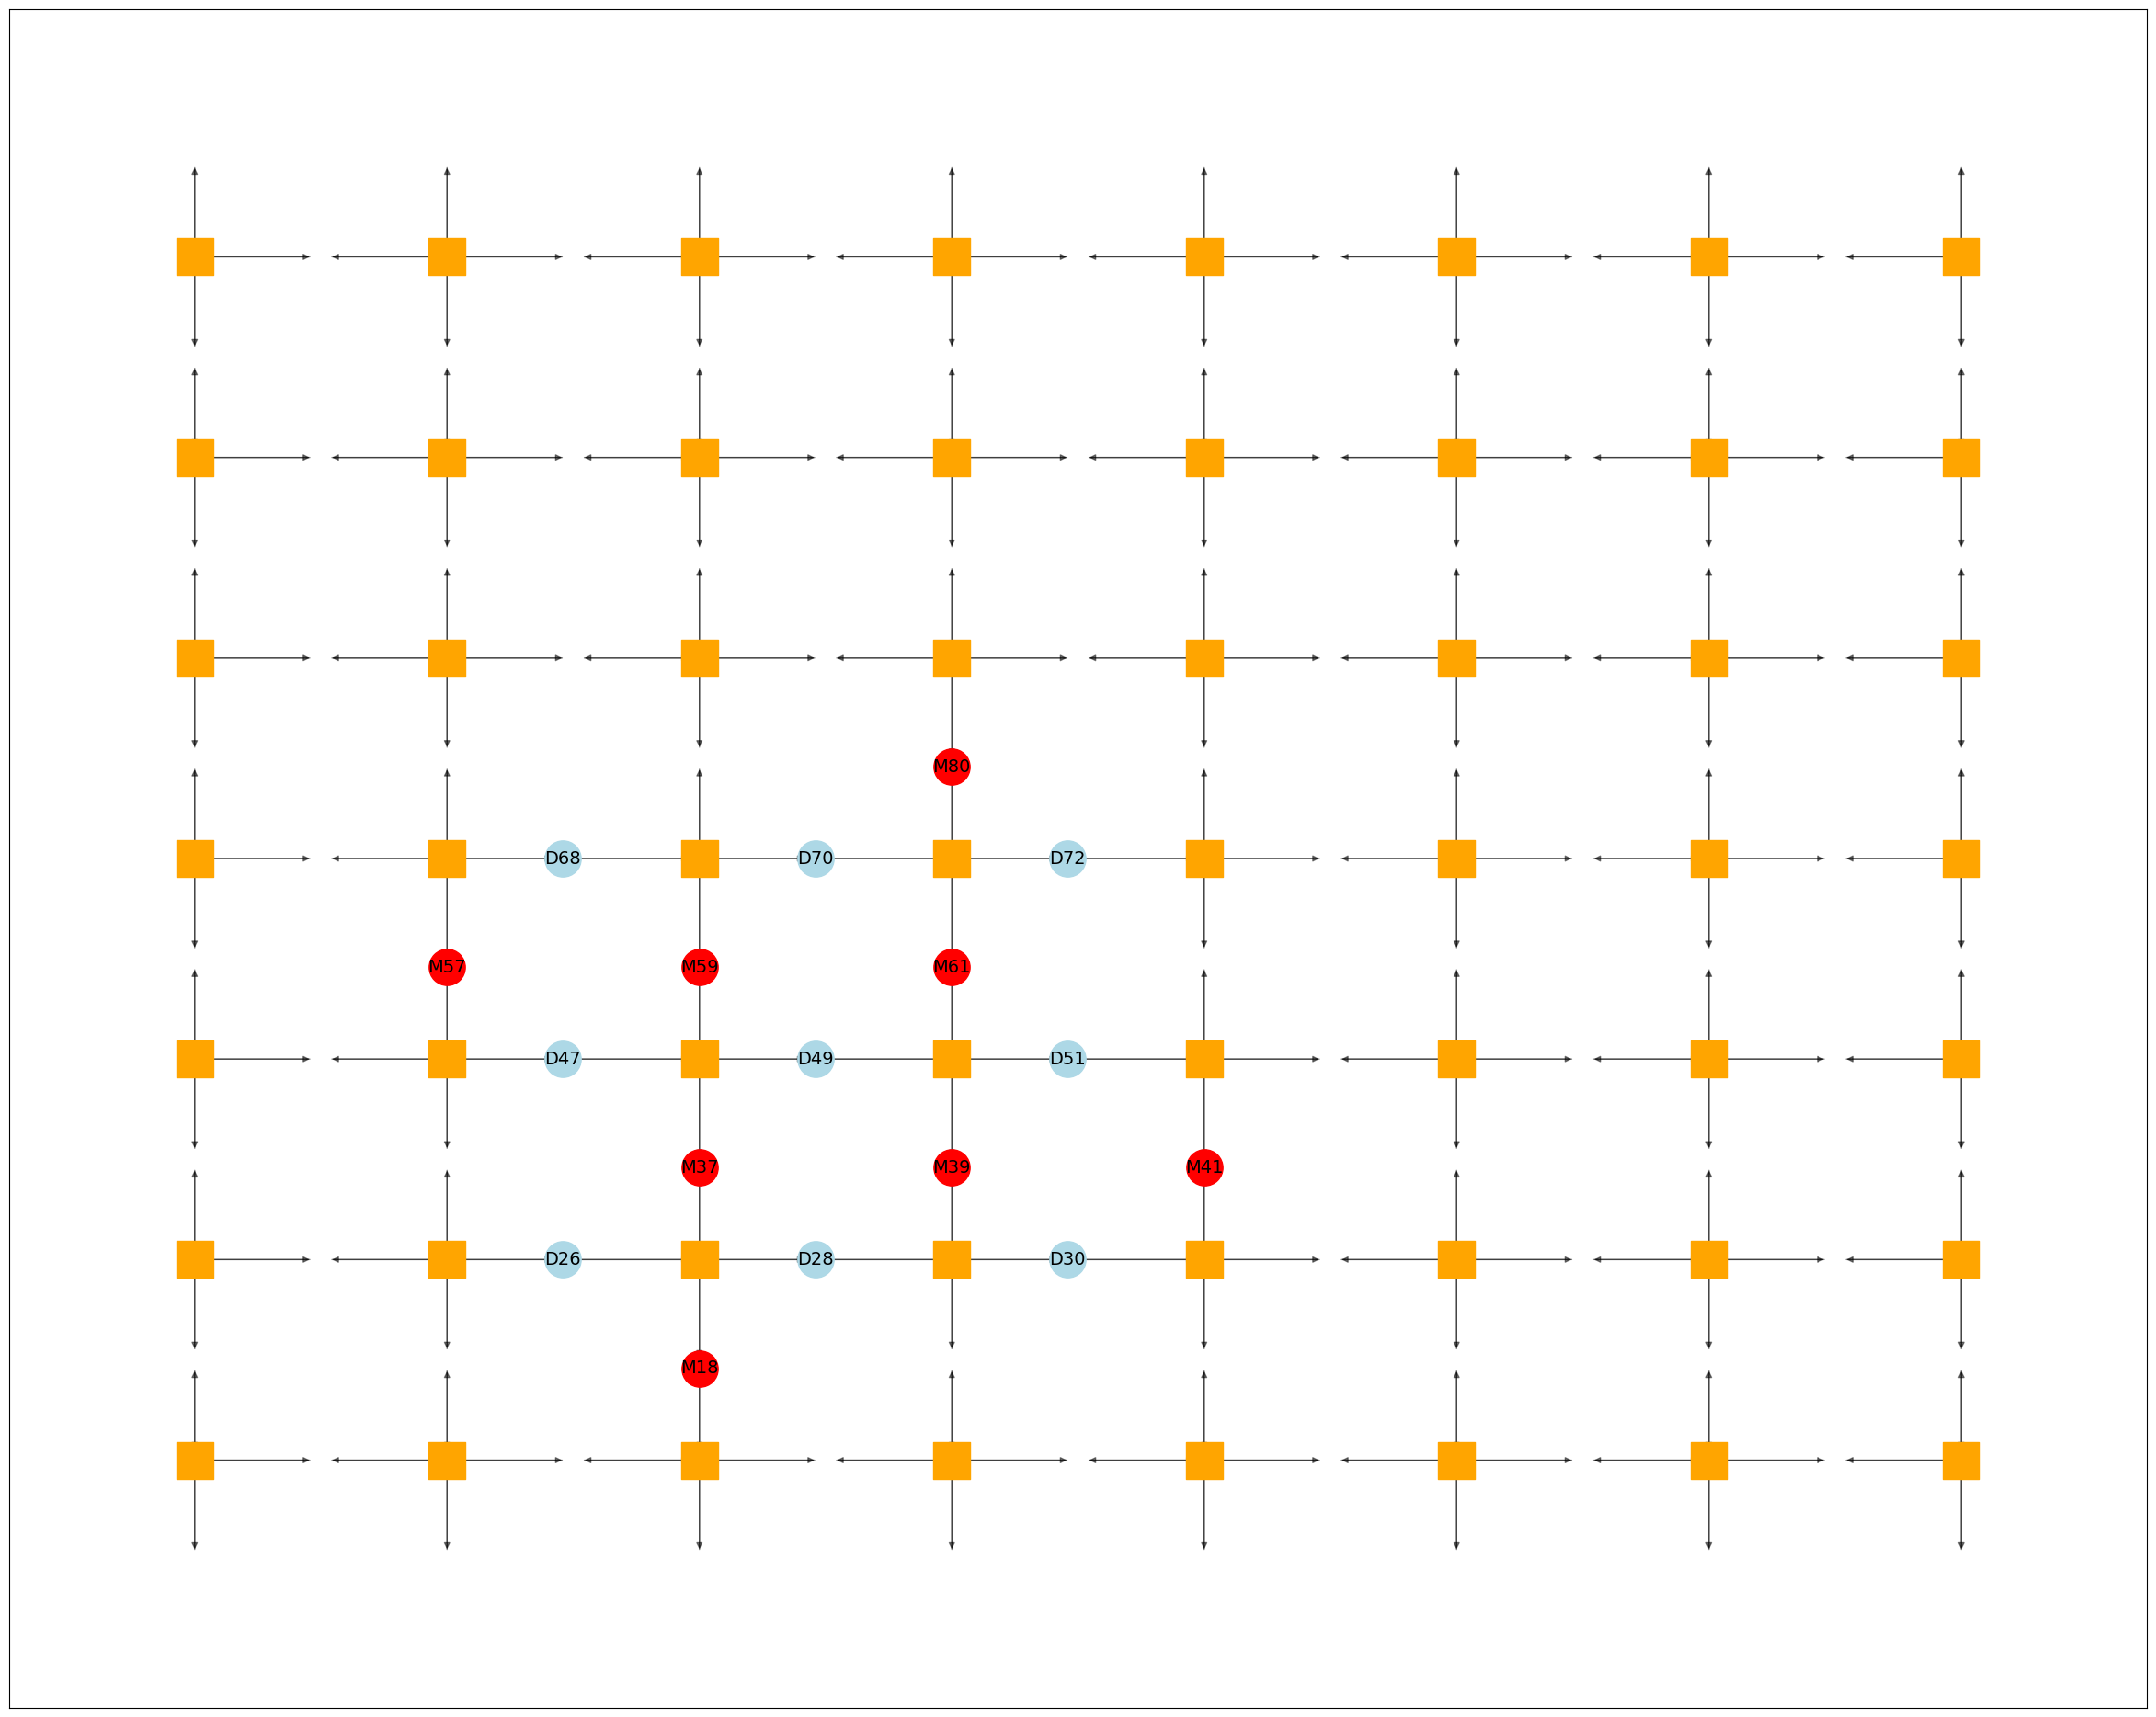

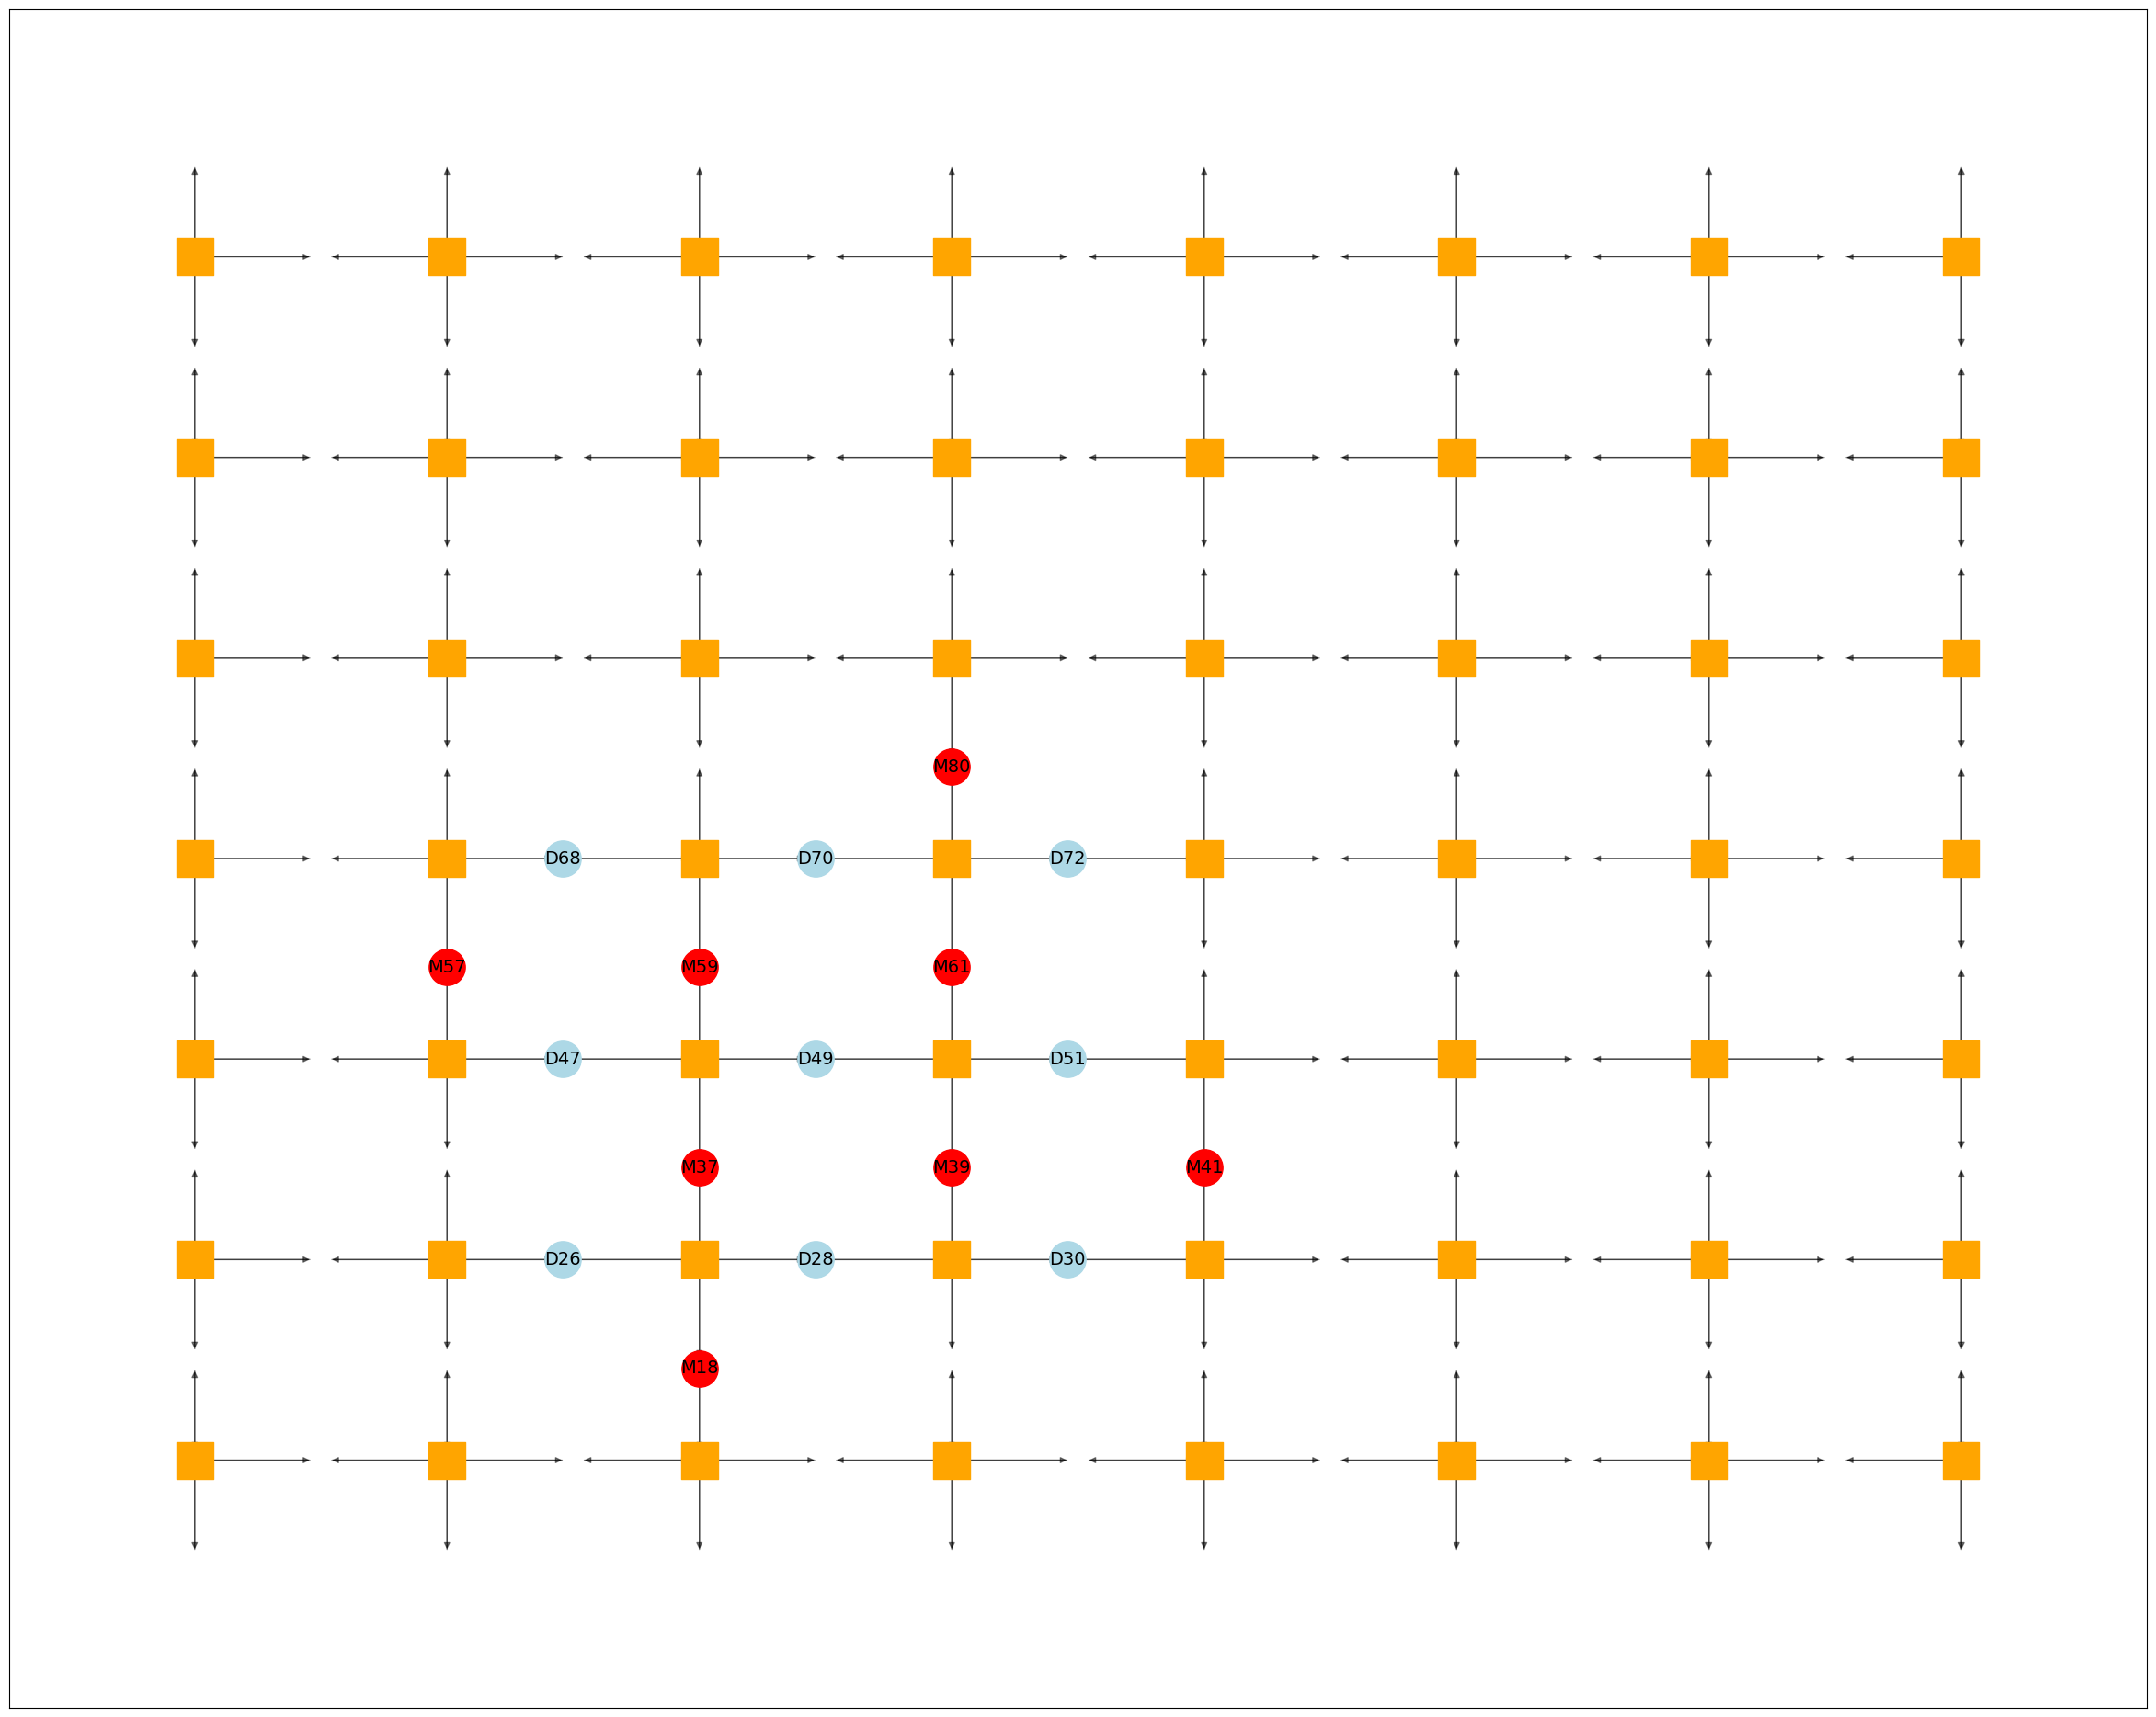

In [13]:
#sc d=2 
arch,circuit, parallelOpsMap = process_circuit(3,2,[1.0],10000)

arch = circuit.resetArch()
arch.refreshGraph()
fig,ax=plt.subplots()
parallelOpsTimes = sorted(parallelOpsMap.keys())
parallelOps = [parallelOpsMap[t] for t in parallelOpsTimes]
time.sleep(10)
ani = FuncAnimation(fig, lambda frame: update(frame, arch), frames=2, repeat=False)
HTML(ani.to_jshtml())

{0: (<src.utils.qccd_nodes.QubitIon object at 0x0000026109247910>, (0.0, 0.0)), 1: (<src.utils.qccd_nodes.QubitIon object at 0x0000026106EF2D50>, (2.0, 2.0)), 2: (<src.utils.qccd_nodes.QubitIon object at 0x0000026109454F90>, (2.0, 4.0)), 3: (<src.utils.qccd_nodes.QubitIon object at 0x0000026106DD0DD0>, (3.0, 0.0)), 4: (<src.utils.qccd_nodes.QubitIon object at 0x0000026106DD1290>, (3.0, 3.0)), 5: (<src.utils.qccd_nodes.QubitIon object at 0x0000026109448090>, (4.0, 2.0)), 6: (<src.utils.qccd_nodes.QubitIon object at 0x000002610990B1D0>, (4.0, 4.0)), 7: (<src.utils.qccd_nodes.QubitIon object at 0x00000261099091D0>, (4.0, 6.0)), 8: (<src.utils.qccd_nodes.QubitIon object at 0x0000026109908F50>, (6.0, 0.0)), 9: (<src.utils.qccd_nodes.QubitIon object at 0x00000261099086D0>, (6.0, 6.0)), 10: (<src.utils.qccd_nodes.QubitIon object at 0x0000026109908310>, (6.0, 8.0)), 11: (<src.utils.qccd_nodes.QubitIon object at 0x000002610990B850>, (7.0, 3.0)), 12: (<src.utils.qccd_nodes.QubitIon object at 0x0

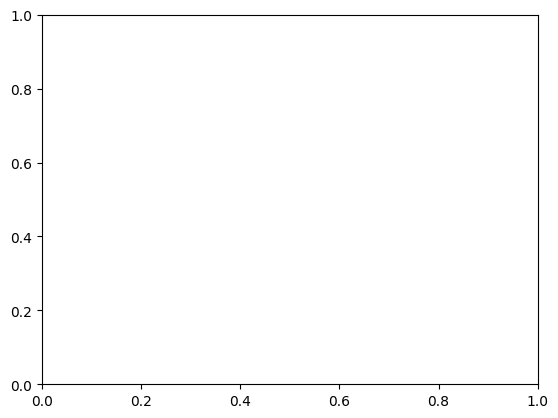

In [13]:
#tri-mapping 488
arch,circuit, parallelOpsMap = get_parallelopsmap(5,1,(4,8,8),'Z',2)

arch = circuit.resetArch()
arch.refreshGraph()
fig,ax=plt.subplots()
parallelOpsTimes = sorted(parallelOpsMap.keys())
parallelOps = [parallelOpsMap[t] for t in parallelOpsTimes]
#time.sleep(10)
#ani = FuncAnimation(fig, lambda frame: update(frame, arch), frames=len(parallelOps)+1, repeat=False)
#HTML(ani.to_jshtml())

In [6]:
import ipywidgets as widgets
from IPython.display import display

def show_frame(frame):
    fig.clf()  # clear figure
    update(frame, arch)
    display(fig)

slider = widgets.IntSlider(min=0, max=len(parallelOps), step=1, value=0)
widgets.interact(show_frame, frame=slider)

interactive(children=(IntSlider(value=0, description='frame', max=282), Output()), _dom_classes=('widget-inter…

<function __main__.show_frame(frame)>

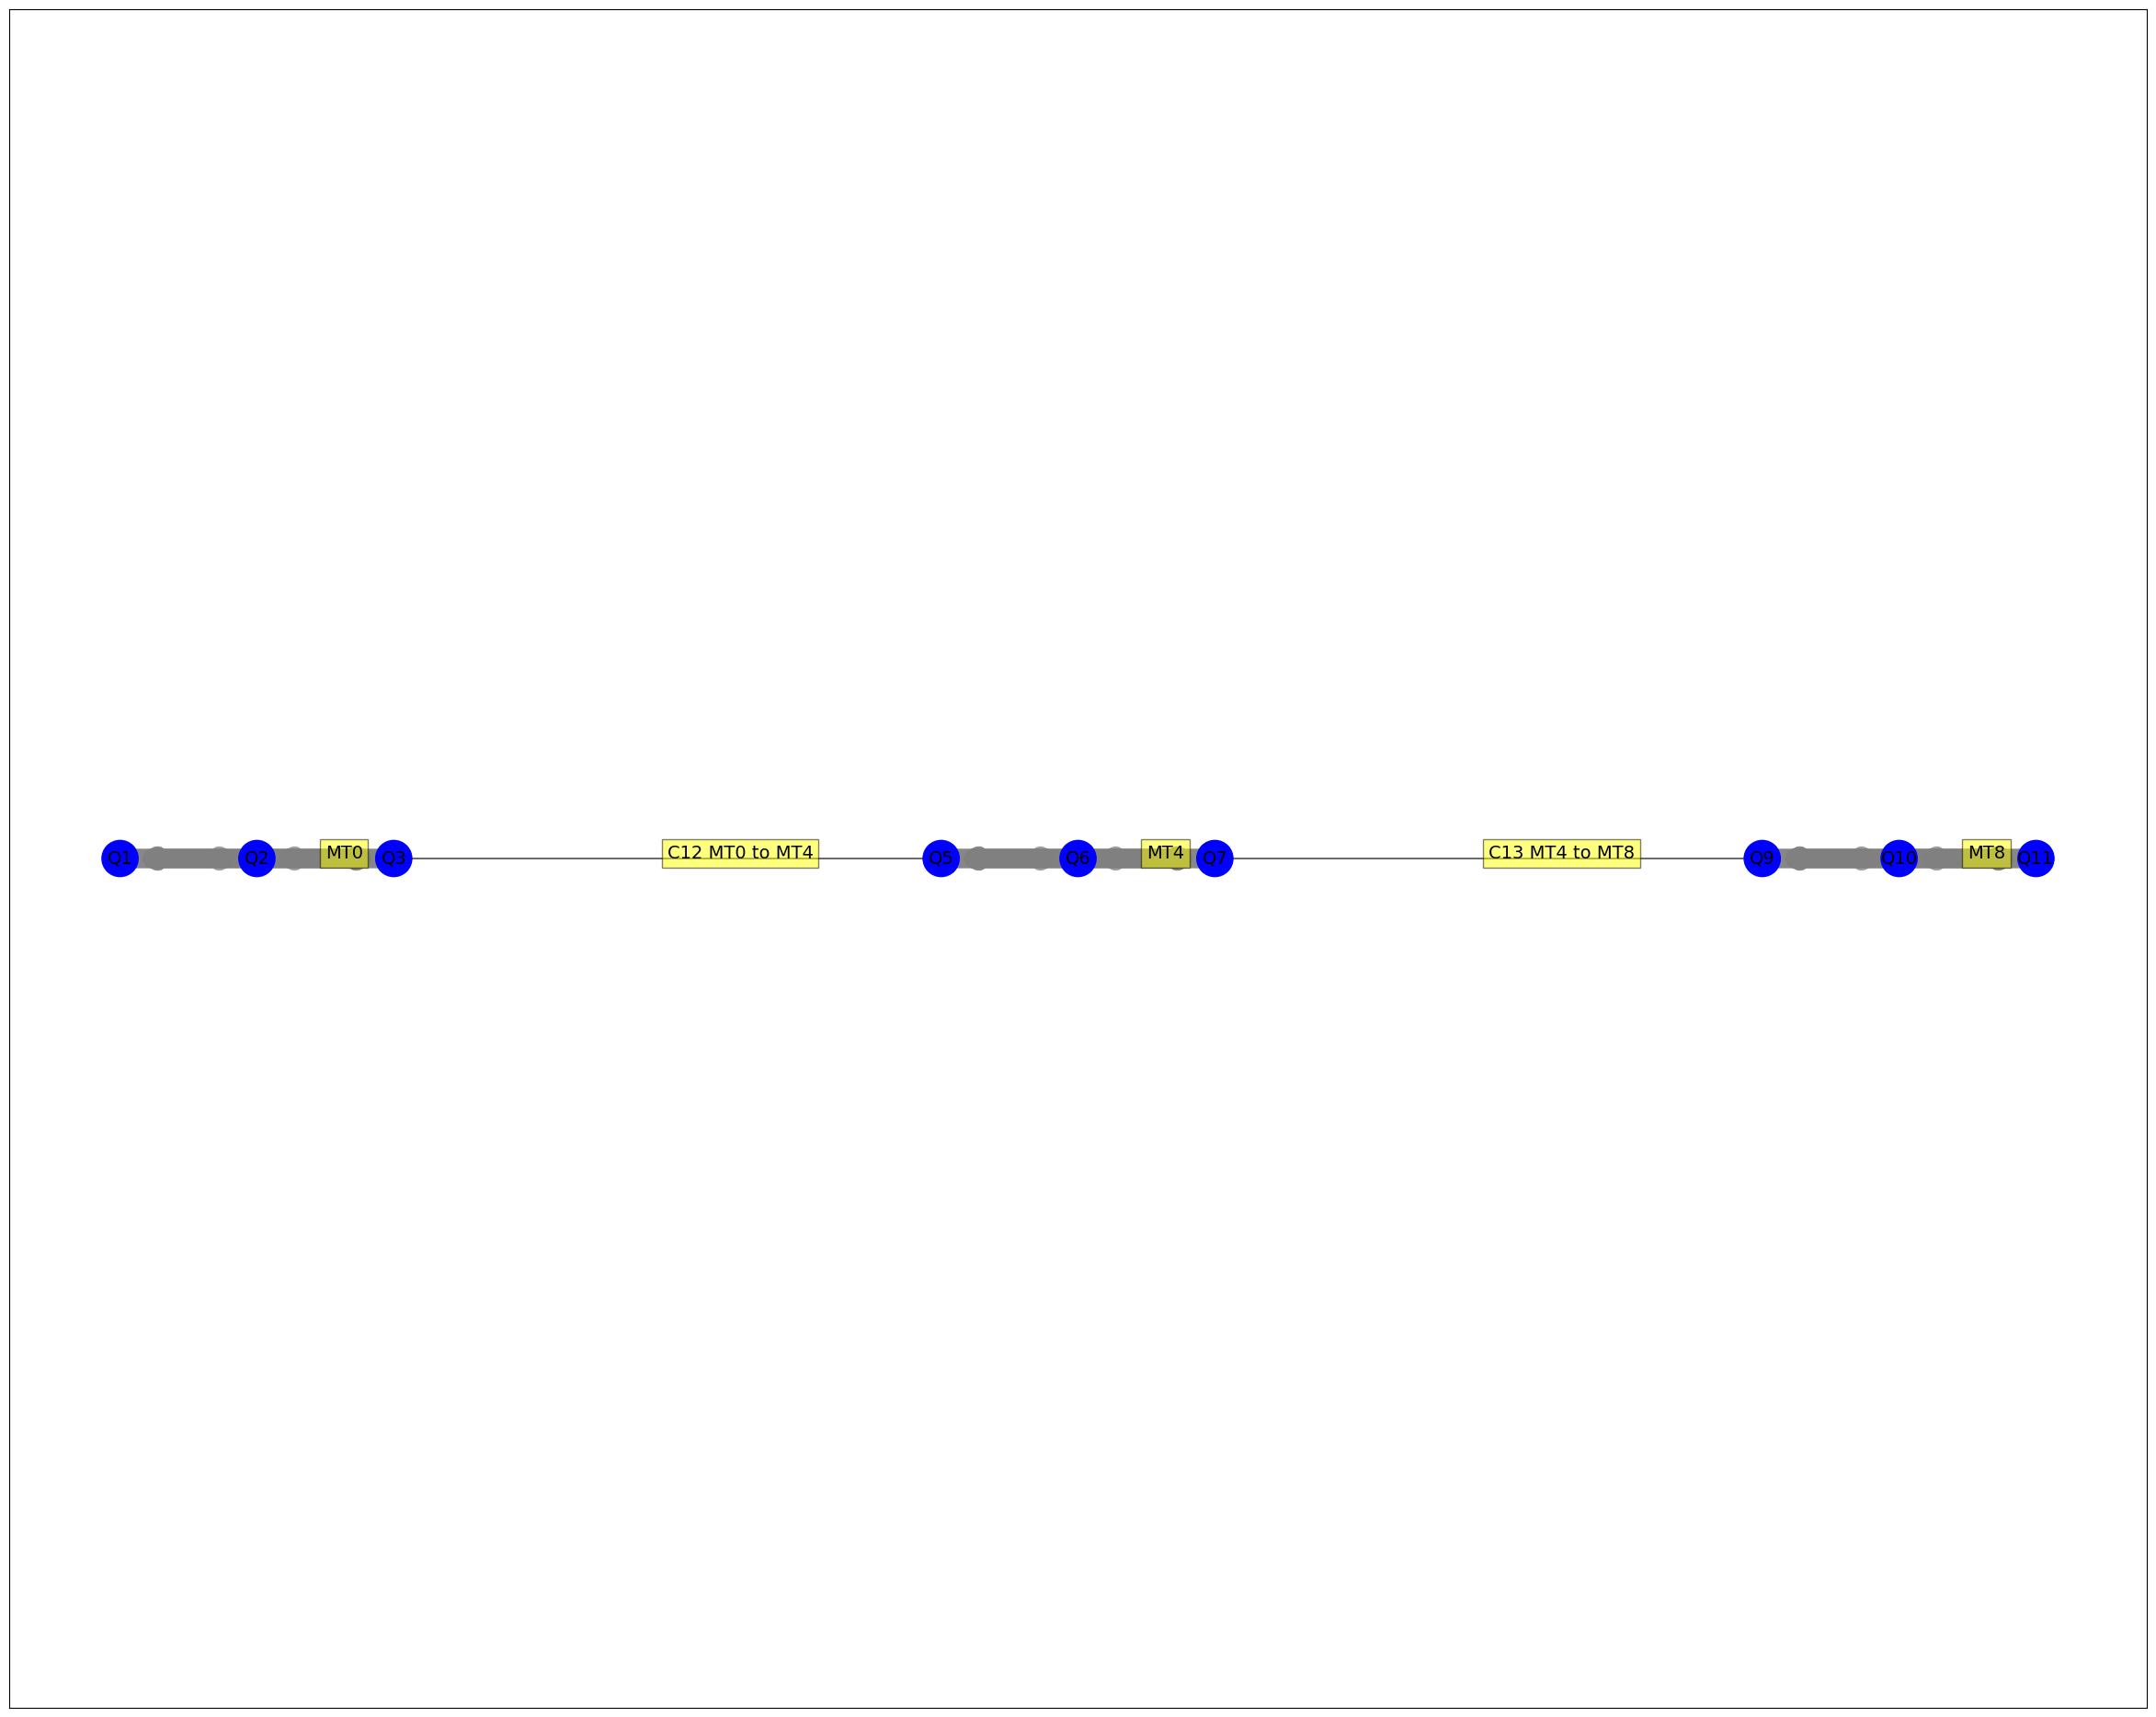

In [3]:
arch = QCCDArch()

ionspacing = 5
trapspacing = 30
cool = 'red'
qubit = 'blue'
traps = []

for i in range(3):
    ions = [QubitIon(qubit, 'Q'), QubitIon(qubit, 'Q'), QubitIon(qubit, 'Q')]
    trap = arch.addManipulationTrap(x=i * trapspacing, y=0, ions=ions, color='grey', spacing=ionspacing, isHorizontal=True)
    traps.append(trap)

for t1,t2 in zip(traps[:-1], traps[1:]):
    arch.addEdge(t1,t2)

arch.refreshGraph()
fig,ax = plt.subplots()
arch.display(fig, ax, showLabels=True)

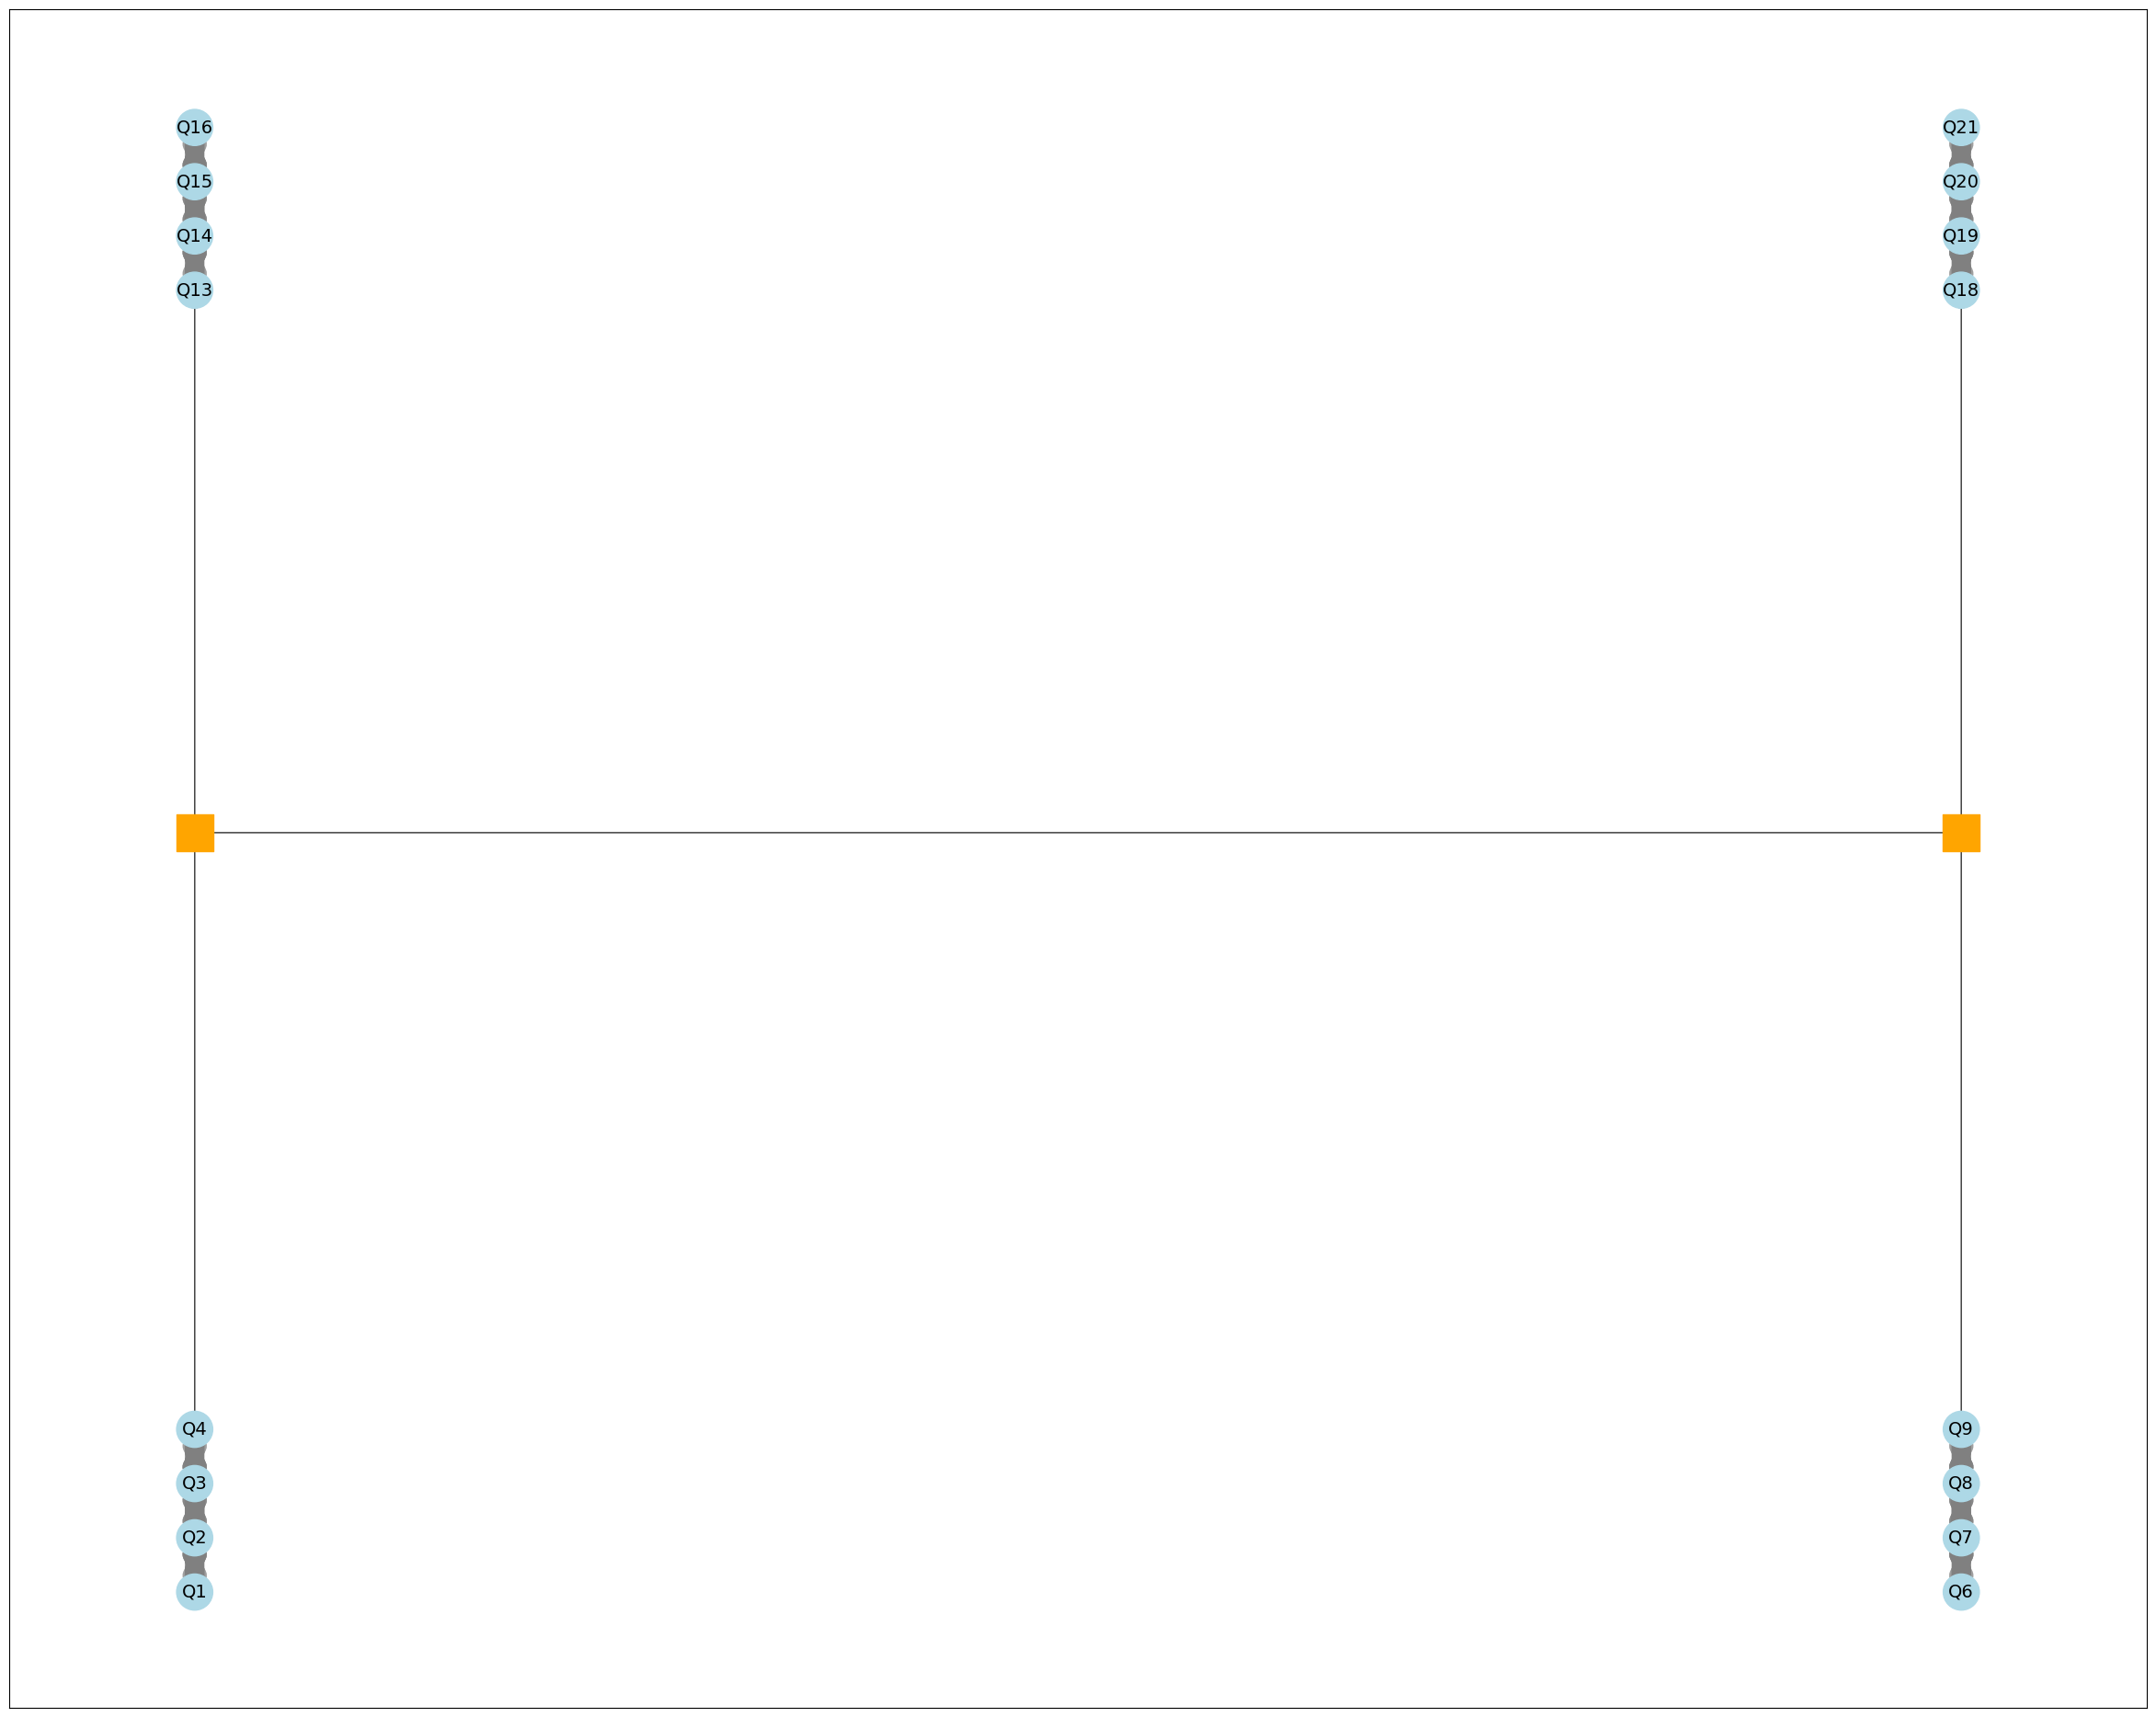

In [4]:
arch = QCCDArch()

ionspacing = 1
trapspacing = 6
qubit_colour = 'red'
qubit_colour = 'lightblue'
junction_colour = 'orange'
traps = []

ManipulationTrap.DEFAULT_SPACING = trapspacing
arch.SIZING = 0.5
ions11 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap11 = arch.addManipulationTrap(x=0, y=0, ions=ions11, color='grey', spacing=ionspacing, isHorizontal=False)

ions12 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap12 = arch.addManipulationTrap(x=trapspacing, y=0, ions=ions12, color='grey', spacing=ionspacing, isHorizontal=False)

junctionL = arch.addJunction(x=0, y=trapspacing, color=junction_colour)
junctionR = arch.addJunction(x=trapspacing, y=trapspacing, color=junction_colour)

ions21 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap21 = arch.addManipulationTrap(x=0, y=2*trapspacing, ions=ions21, color='grey', spacing=ionspacing, isHorizontal=False)

ions22 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap22 = arch.addManipulationTrap(x=trapspacing, y=2*trapspacing, ions=ions22, color='grey', spacing=ionspacing, isHorizontal=False)

crossing11 = arch.addEdge(trap11, junctionL)
arch.addEdge(trap12, junctionR)
crossing21 = arch.addEdge(trap21, junctionL)
arch.addEdge(trap22, junctionR)
arch.addEdge(junctionL, junctionR)

arch.refreshGraph()
# Display architecture
fig, ax = plt.subplots()
# Display architecture
arch.display(fig,ax, showLabels=False)

In [5]:
from src.compiler.qccd_parallelisation import *

ops = (
    Split.physicalOperation(trap11, crossing11), 
    Move.physicalOperation(crossing11),
    JunctionCrossing.physicalOperation(junctionL, crossing11),
    JunctionCrossing.physicalOperation(junctionL, crossing21),
    Move.physicalOperation(crossing21),
    Merge.physicalOperation(trap21, crossing21),
    GateSwap.physicalOperation(trap=trap21, ion1=ions21[0], ion2=ions21[2]),
    TwoQubitMSGate.physicalOperation(ion1=ions22[0], ion2=ions22[2],trap=trap22),
    OneQubitGate.physicalOperation(ion=ions12[0], trap=trap12),
    Measurement.physicalOperation(ion=ions12[0], trap=trap12),
    QubitReset.physicalOperation(ion=ions12[0],trap=trap12))
parallelOps = paralleliseOperationsSimple(ops)

print(parallelOps)

[<src.utils.qccd_operations.ParallelOperation object at 0x000001F9395A3B60>, <src.utils.qccd_operations.ParallelOperation object at 0x000001F93B8C0550>, <src.utils.qccd_operations.ParallelOperation object at 0x000001F93B8C0690>, <src.utils.qccd_operations.ParallelOperation object at 0x000001F93969C640>, <src.utils.qccd_operations.ParallelOperation object at 0x000001F93969D480>, <src.utils.qccd_operations.ParallelOperation object at 0x000001F9396767B0>, <src.utils.qccd_operations.ParallelOperation object at 0x000001F939629BF0>]


QUBIT_RESET[19]
QUBIT_RESET[10]
QUBIT_RESET[23]
QUBIT_RESET[12]
QUBIT_RESET[30]
QUBIT_RESET[42]
QUBIT_RESET[33]
QUBIT_RESET[36]
QUBIT_RESET[52]
QUBIT_RESET[55]
QUBIT_RESET[45]
QUBIT_RESET[46]
QUBIT_RESET[62]
QUBIT_RESET[63]
QUBIT_RESET[66]
QUBIT_RESET[67]
QUBIT_RESET[17]
QUBIT_RESET[21]
QUBIT_RESET[18]
QUBIT_RESET[9]
QUBIT_RESET[22]
QUBIT_RESET[28]
QUBIT_RESET[29]
QUBIT_RESET[41]
QUBIT_RESET[32]
QUBIT_RESET[35]
QUBIT_RESET[51]
QUBIT_RESET[54]
QUBIT_RESET[44]
QUBIT_RESET[61]
QUBIT_RESET[65]
RY[17]
RX[17]
RY[21]
RX[21]
RY[9]
RX[9]
RY[29]
RX[29]
RY[32]
RX[32]
RY[54]
RX[54]
RY[61]
RX[61]
RY[65]
RX[65]
RY[17]
RX[17]
RX[10]
TWO_QUBIT_MS_GATE[17, 10]
RY[17]
RY[29]
RX[29]
RX[55]
TWO_QUBIT_MS_GATE[29, 55]
RY[29]
RY[9]
RX[9]
RX[33]
TWO_QUBIT_MS_GATE[9, 33]
RY[9]
RY[54]
RX[54]
RX[66]
TWO_QUBIT_MS_GATE[54, 66]
RY[54]
RY[21]
RX[21]
RX[12]
TWO_QUBIT_MS_GATE[21, 12]
RY[21]
RY[32]
RX[32]
RX[46]
TWO_QUBIT_MS_GATE[32, 46]
RY[32]
RY[52]
RX[52]
RX[28]
TWO_QUBIT_MS_GATE[52, 28]
RY[52]
RY[42]
RX[42]
RX[18]


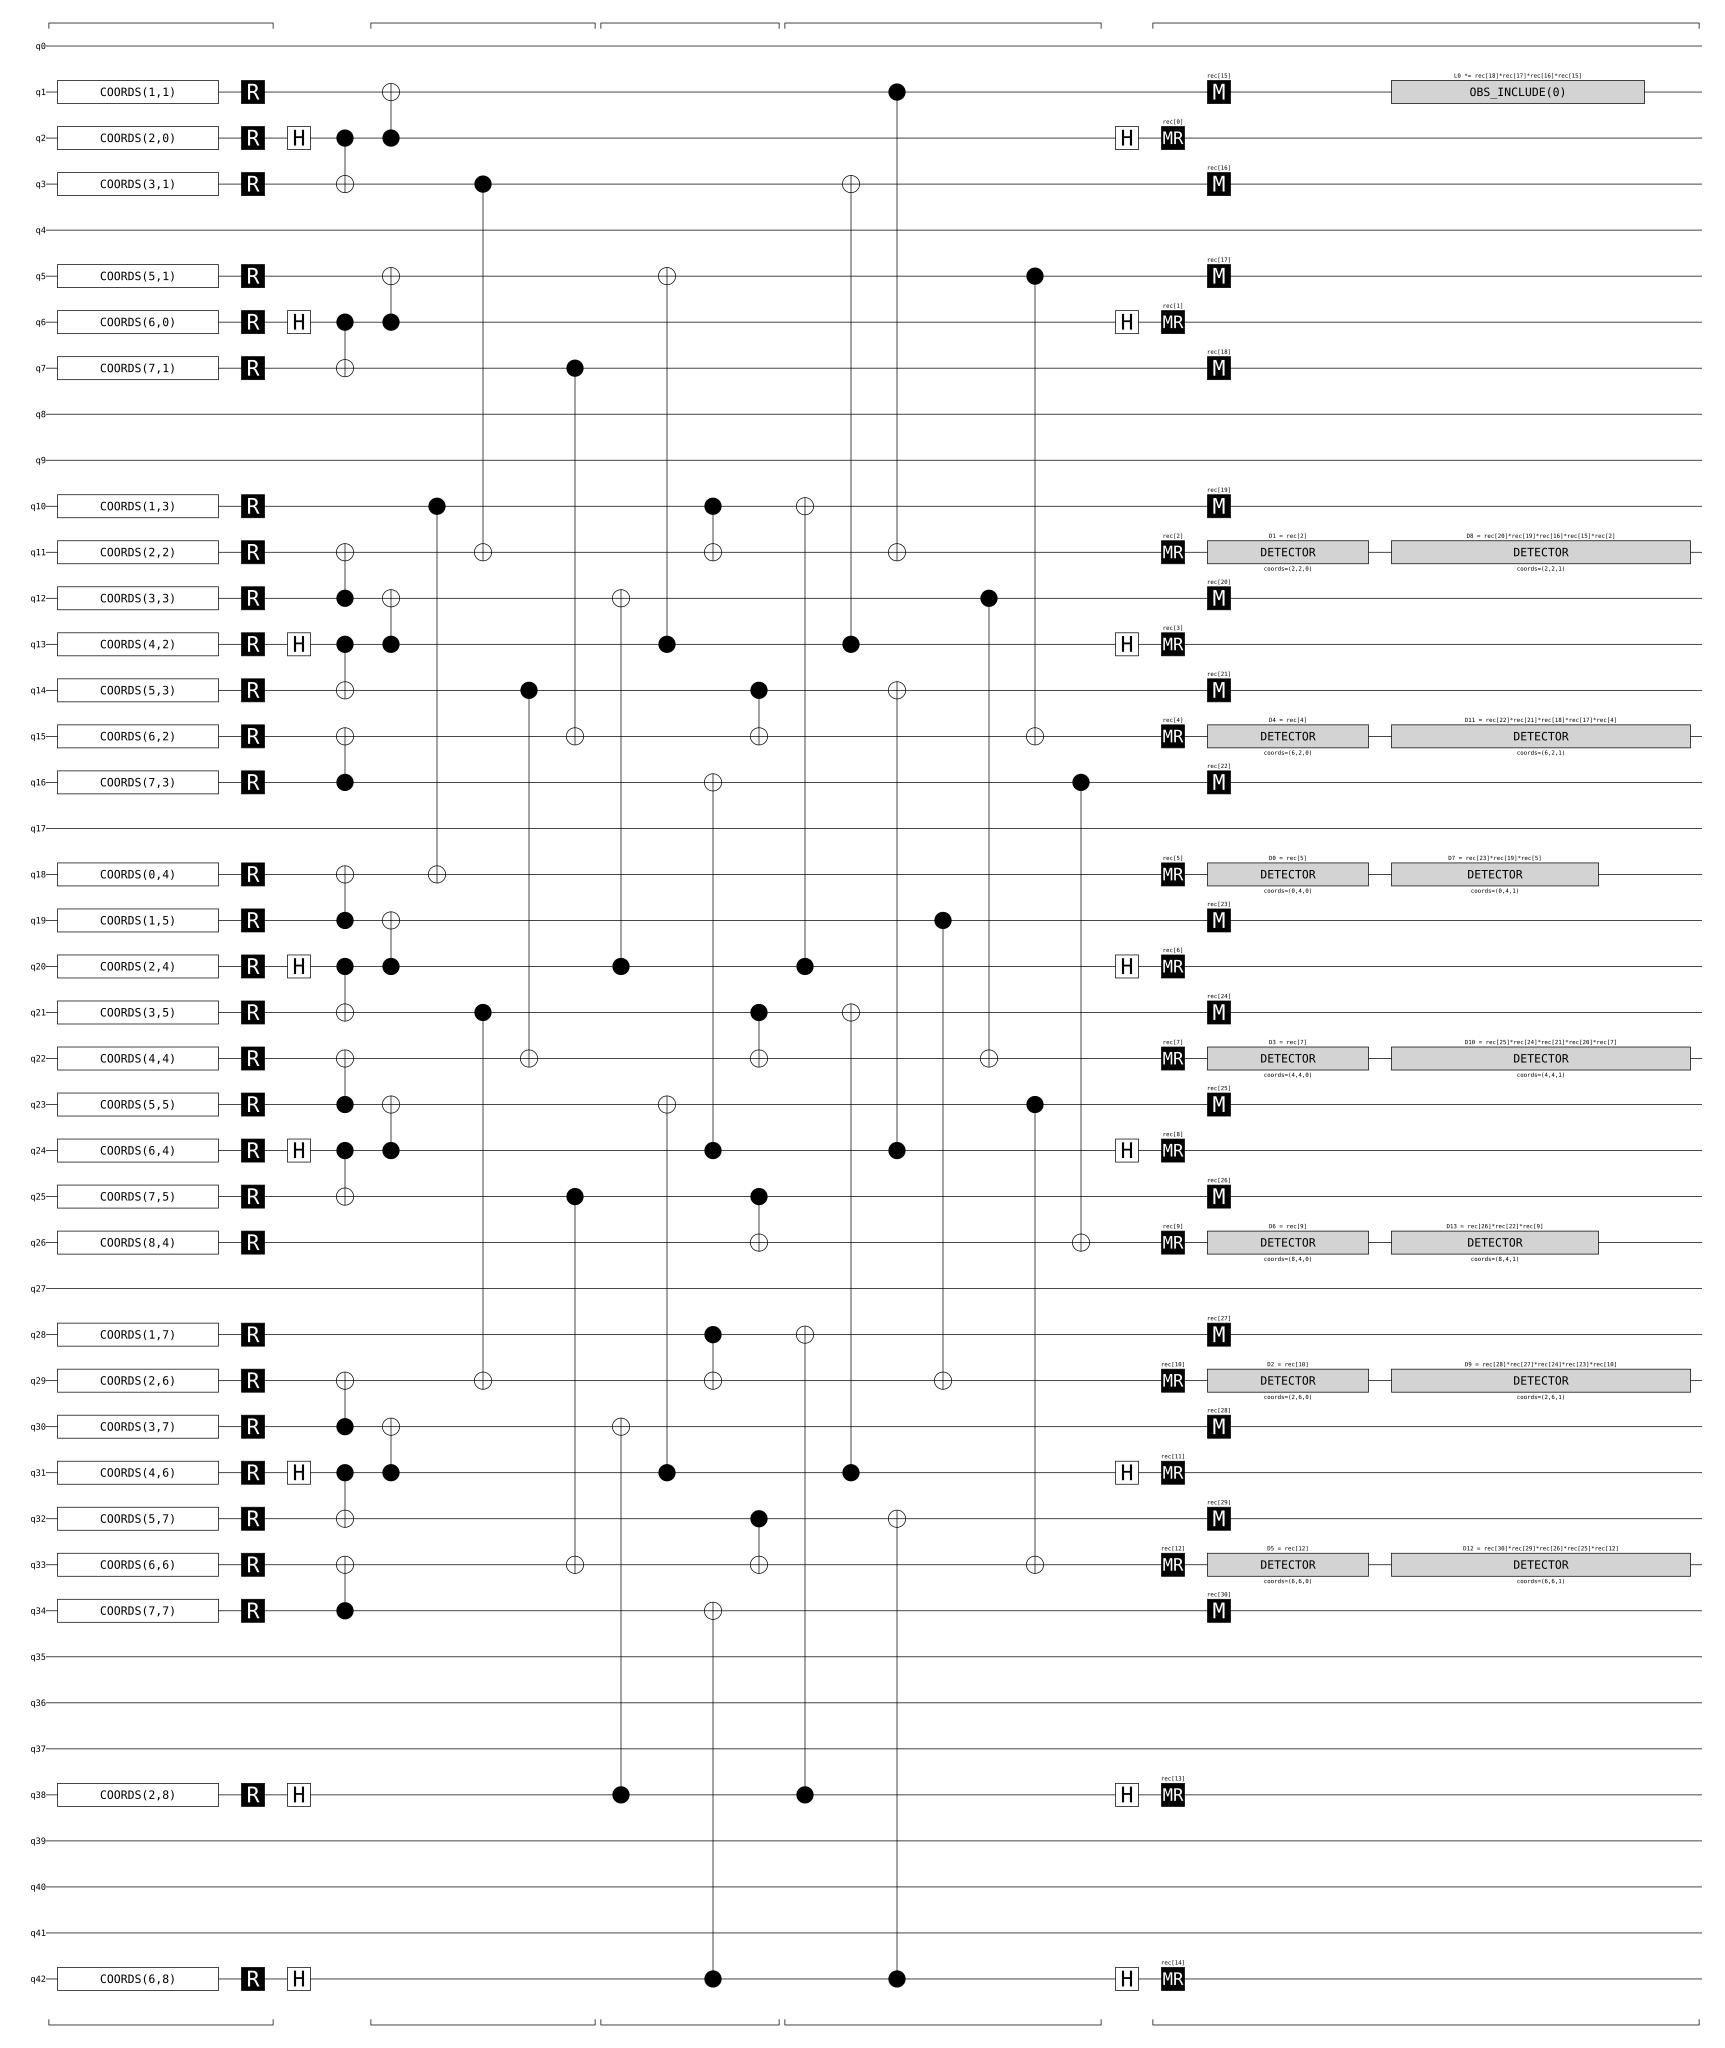

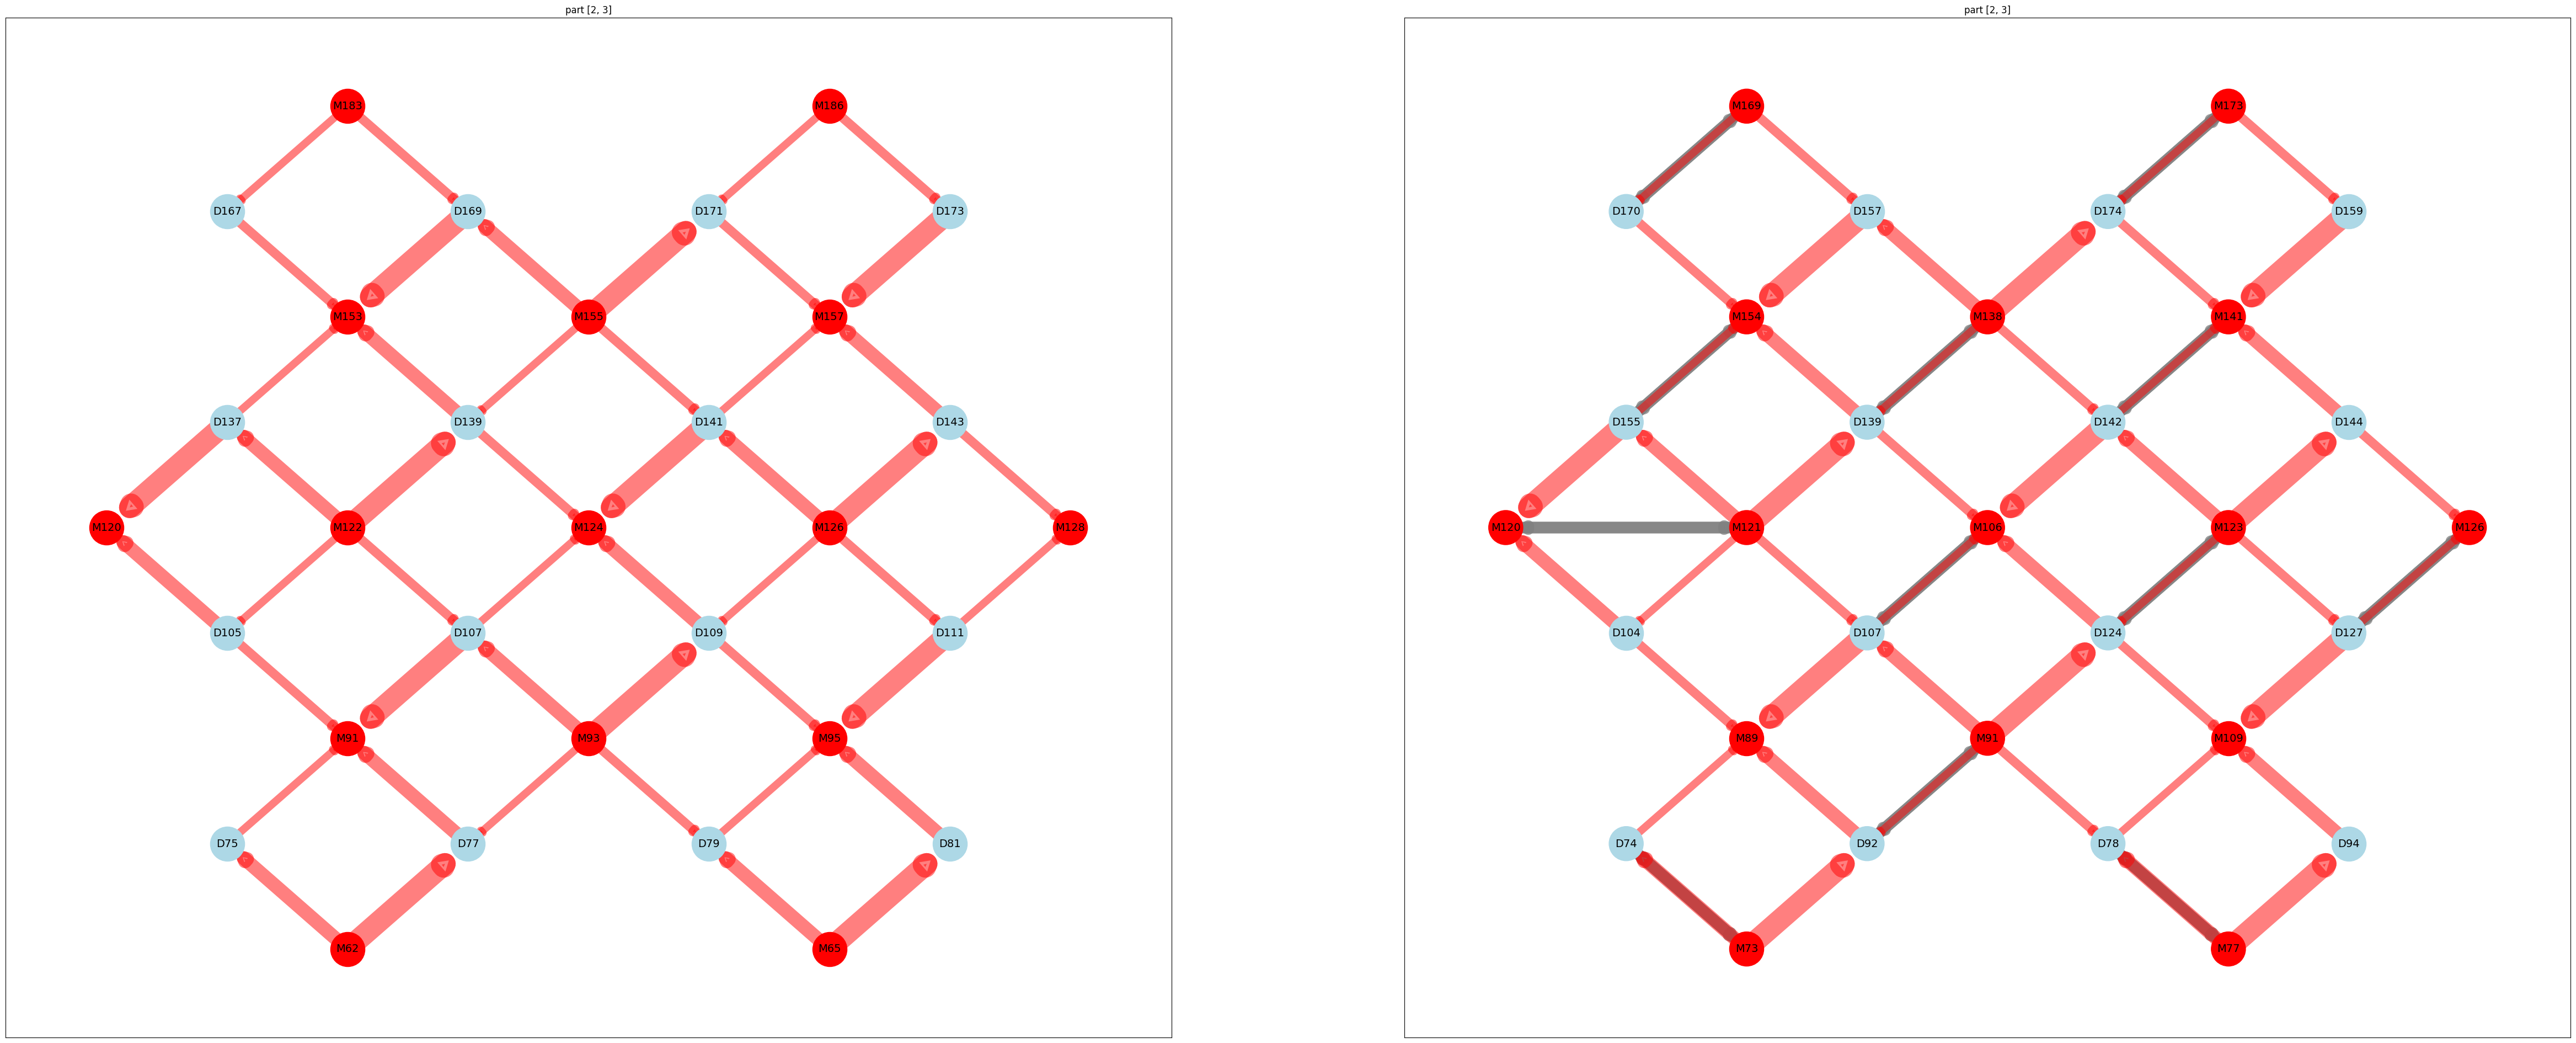

In [6]:
from src.simulator.qccd_circuit import *

noise = 1e-3
d=4
    
circuit = QCCDCircuit.generated(
    "surface_code:rotated_memory_z",
    rounds=1,
    distance=d,
    after_clifford_depolarization=noise,
    after_reset_flip_probability=noise,
    before_measure_flip_probability=noise,
    before_round_data_depolarization=noise,
)


rows = 4
cols = 4
capacity = 4

arch, (instructions,_) = circuit.processCircuitAugmentedGrid(rows=rows, cols=cols, trapCapacity=capacity)

for i in instructions:
    print(i.label+str([ion.idx for ion in i.ions]))

_capacities = [2,3]
rows = 10
cols = 10

label='part'
fig, axs = plt.subplots(1, len(_capacities))
for ax, capacity in zip(axs, _capacities):
    arch1, (instructions,_) = circuit.processCircuitAugmentedGrid(rows=rows, cols=cols, trapCapacity=capacity)
    arch1.ION_SIZE = 2000

    for idx, (ion, pos) in circuit._ionMapping.items():
        ion.set(ion.idx, pos[0], pos[1])

    arch1.refreshGraph()
    edgesDups = []
    edgesPos = []
    ionsInvolved = set()
    score = 0
    for op in instructions:
        if not isinstance(op, TwoQubitMSGate):
            continue
        if not ionsInvolved.isdisjoint(op.ions):
            score+=1
            ionsInvolved=set()
        edgesDups.append((op.ions, score))
        edgesPos.append((op.ionsActedIdxs, score))
        ionsInvolved=ionsInvolved.union(op.ions)
    scores = [score for ((ion1,ion2), score) in edgesDups]
    color_from_score = {s: (5+i*i)*2 for i, s in enumerate( sorted(list(set(scores)), reverse=True))}
    arch1._manipulationTraps.append(([(ion1.idx, ion2.idx) for ((ion1,ion2), score) in edgesDups], [color_from_score[score] for ((ion1,ion2), score) in edgesDups]))
    arch1.display(fig, ax, showLabels=False, showEdges=False, show_junction=False)
    ax.set_title(f"{label} {_capacities}")

#print(circuit.circuitString())
circuit.without_noise().diagram('timeline-svg')

In [7]:
from src.simulator.qccd_circuit import *
noise = 1e-3
d=3
    
circuit = QCCDCircuit.generated(
    "color_code:memory_xyz",
    rounds=2,
    distance=d,
    after_clifford_depolarization=noise,
    after_reset_flip_probability=noise,
    before_measure_flip_probability=noise,
    before_round_data_depolarization=noise,
)


rows = 4
cols = 4
capacity = 4

print(circuit.circuitString())
arch, (instructions,_) = circuit.processCircuitAugmentedGrid(rows=rows, cols=cols, trapCapacity=capacity)

for i in instructions:
    print(i.label+str([ion.idx for ion in i.ions]))

_capacities = [2,3]
rows = 10
cols = 10

label='part'
fig, axs = plt.subplots(1, len(_capacities))
for ax, capacity in zip(axs, _capacities):
    arch1, (instructions,_) = circuit.processCircuitAugmentedGrid(rows=rows, cols=cols, trapCapacity=capacity)
    arch1.ION_SIZE = 2000

    for idx, (ion, pos) in circuit._ionMapping.items():
        ion.set(ion.idx, pos[0], pos[1])

    arch1.refreshGraph()
    edgesDups = []
    edgesPos = []
    ionsInvolved = set()
    score = 0
    for op in instructions:
        if not isinstance(op, TwoQubitMSGate):
            continue
        if not ionsInvolved.isdisjoint(op.ions):
            score+=1
            ionsInvolved=set()
        edgesDups.append((op.ions, score))
        edgesPos.append((op.ionsActedIdxs, score))
        ionsInvolved=ionsInvolved.union(op.ions)
    scores = [score for ((ion1,ion2), score) in edgesDups]
    color_from_score = {s: (5+i*i)*2 for i, s in enumerate( sorted(list(set(scores)), reverse=True))}
    arch1._manipulationTraps.append(([(ion1.idx, ion2.idx) for ((ion1,ion2), score) in edgesDups], [color_from_score[score] for ((ion1,ion2), score) in edgesDups]))
    arch1.display(fig, ax, showLabels=False, showEdges=False, show_junction=False)
    ax.set_title(f"{label} {_capacities}")


circuit.without_noise().diagram('timeline-svg')

['QUBIT_COORDS(0, 0) 0', 'QUBIT_COORDS(1, 0) 1', 'QUBIT_COORDS(2, 0) 2', 'QUBIT_COORDS(3, 0) 3', 'QUBIT_COORDS(0.5, 1) 4', 'QUBIT_COORDS(1.5, 1) 5', 'QUBIT_COORDS(2.5, 1) 6', 'QUBIT_COORDS(1, 2) 7', 'QUBIT_COORDS(2, 2) 8', 'QUBIT_COORDS(1.5, 3) 9', 'R 0', 'R 1', 'R 2', 'R 3', 'R 4', 'R 5', 'R 6', 'R 7', 'R 8', 'R 9', 'S 0 1 3 5 6 7 9 0 1 3 5 6 7 9 0 1 3 5 6 7 9', 'H 0', 'H 1', 'H 3', 'H 5', 'H 6', 'H 7', 'H 9', 'CNOT 5 4', 'CNOT 3 2', 'BARRIER', 'CNOT 7 4', 'CNOT 6 2', 'BARRIER', 'CNOT 1 4', 'CNOT 6 8', 'BARRIER', 'CNOT 1 2', 'CNOT 7 8', 'BARRIER', 'CNOT 5 2', 'CNOT 9 8', 'BARRIER', 'CNOT 0 4', 'CNOT 5 8', 'BARRIER', 'M 2', 'M 4', 'M 8', 'R 2', 'R 4', 'R 8', 'S 0 1 3 5 6 7 9 0 1 3 5 6 7 9 0 1 3 5 6 7 9', 'H 0', 'H 1', 'H 3', 'H 5', 'H 6', 'H 7', 'H 9', 'CNOT 5 4', 'CNOT 3 2', 'BARRIER', 'CNOT 7 4', 'CNOT 6 2', 'BARRIER', 'CNOT 1 4', 'CNOT 6 8', 'BARRIER', 'CNOT 1 2', 'CNOT 7 8', 'BARRIER', 'CNOT 5 2', 'CNOT 9 8', 'BARRIER', 'CNOT 0 4', 'CNOT 5 8', 'BARRIER', 'M 2', 'M 4', 'M 8', 'R 2',

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


IndexError: invalid index to scalar variable.

In [ ]:
circuit = QCCDCircuit.generated(
    "color_code:memory_xyz",
    rounds=2, # One round is enough to show the layout
    distance=5,
    after_clifford_depolarization=1e-3
)
circuit.diagram(type='detector-slice-svg')

In [ ]:
%pip install svgwrite

In [ ]:
from src.color_code_utils.color_code_circuits import color_code_circuit_666

cc = color_code_circuit_666.ColorCodeCircuit666(3,5)
cc.circuit

In [11]:
from src.simulator.qccd_circuit import *

noise = 1e-3
d=3
circuit = QCCDCircuit.generate_color_code(3,1,(6,6,6))
circuit1 = QCCDCircuit.generated(
    "surface_code:rotated_memory_z",
    rounds=2,
    distance=d,
    after_clifford_depolarization=noise,
    after_reset_flip_probability=noise,
    before_measure_flip_probability=noise,
    before_round_data_depolarization=noise,
)
rows = 4
cols = 4
capacity = 4
arch, (instructions,_) = circuit.processCircuitAugmentedGrid(rows=rows, cols=cols, trapCapacity=capacity)

for i in instructions:
    print(i.label+str([ion.idx for ion in i.ions]))


QUBIT_RESET[44]
QUBIT_RESET[25]
QUBIT_RESET[37]
QUBIT_RESET[26]
QUBIT_RESET[29]
QUBIT_RESET[45]
QUBIT_RESET[30]
QUBIT_RESET[27]
QUBIT_RESET[31]
QUBIT_RESET[38]
RY[27]
RX[27]
RX[26]
TWO_QUBIT_MS_GATE[27, 26]
RY[27]
RY[38]
RX[38]
RX[29]
TWO_QUBIT_MS_GATE[38, 29]
RY[38]
RY[31]
RX[31]
RX[30]
TWO_QUBIT_MS_GATE[31, 30]
RY[31]
RY[27]
RX[27]
RX[37]
TWO_QUBIT_MS_GATE[27, 37]
RY[27]
RY[27]
RX[27]
RX[25]
TWO_QUBIT_MS_GATE[27, 25]
RY[27]
RY[38]
RX[38]
RX[37]
TWO_QUBIT_MS_GATE[38, 37]
RY[38]
RY[31]
RX[31]
RX[29]
TWO_QUBIT_MS_GATE[31, 29]
RY[31]
RY[27]
RX[27]
RX[44]
TWO_QUBIT_MS_GATE[27, 44]
RY[27]
RY[31]
RX[31]
RX[26]
TWO_QUBIT_MS_GATE[31, 26]
RY[31]
RY[38]
RX[38]
RX[44]
TWO_QUBIT_MS_GATE[38, 44]
RY[38]
RY[31]
RX[31]
RX[37]
TWO_QUBIT_MS_GATE[31, 37]
RY[31]
RY[38]
RX[38]
RX[45]
TWO_QUBIT_MS_GATE[38, 45]
RY[38]
RY[31]
RX[31]
RY[27]
RX[27]
RY[38]
RX[38]
MEASUREMENT[31]
MEASUREMENT[27]
MEASUREMENT[38]
QUBIT_RESET[31]
QUBIT_RESET[27]
QUBIT_RESET[38]
RY[31]
RX[31]
RY[27]
RX[27]
RY[38]
RX[38]
RY[26]
RX[26

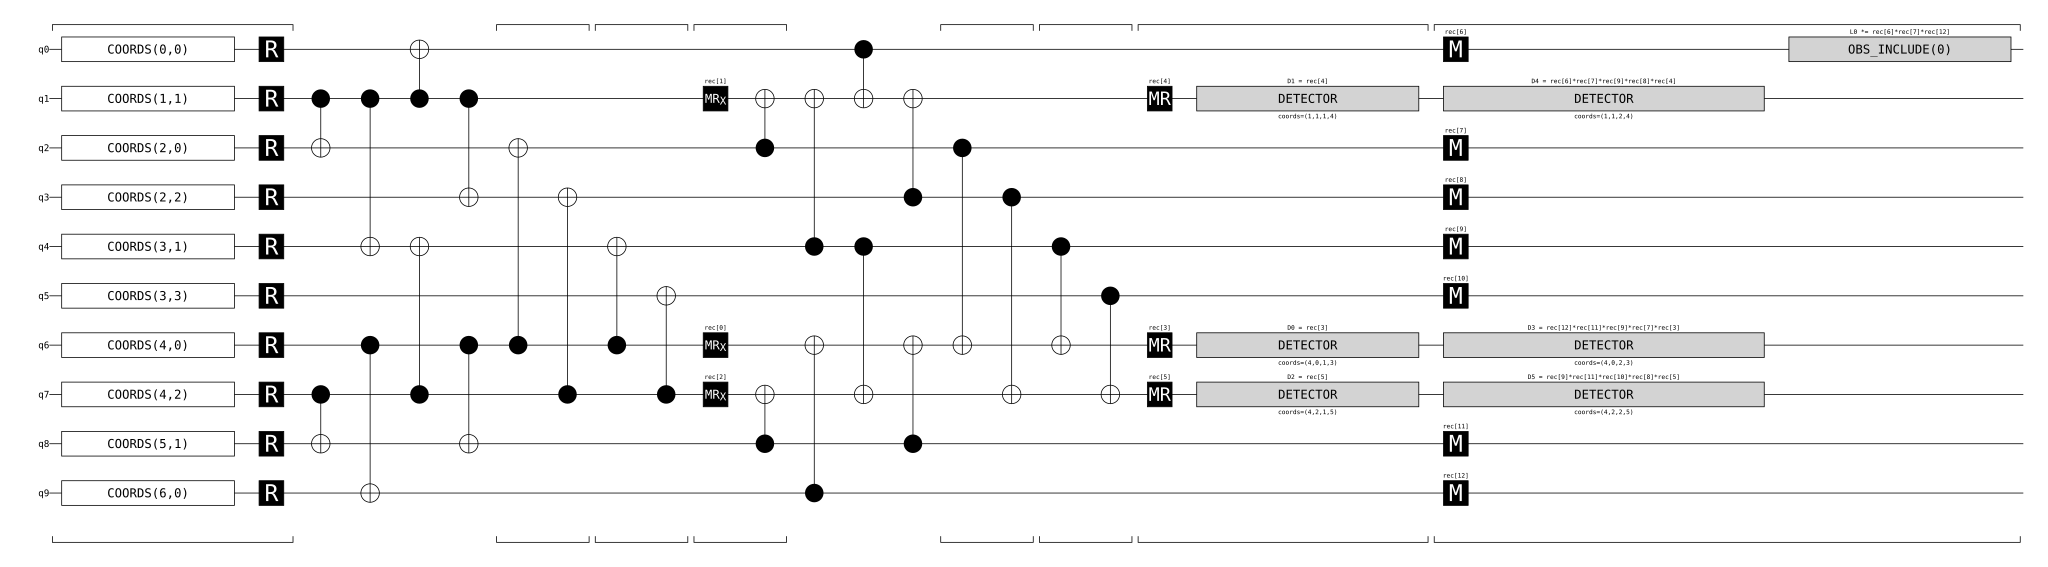

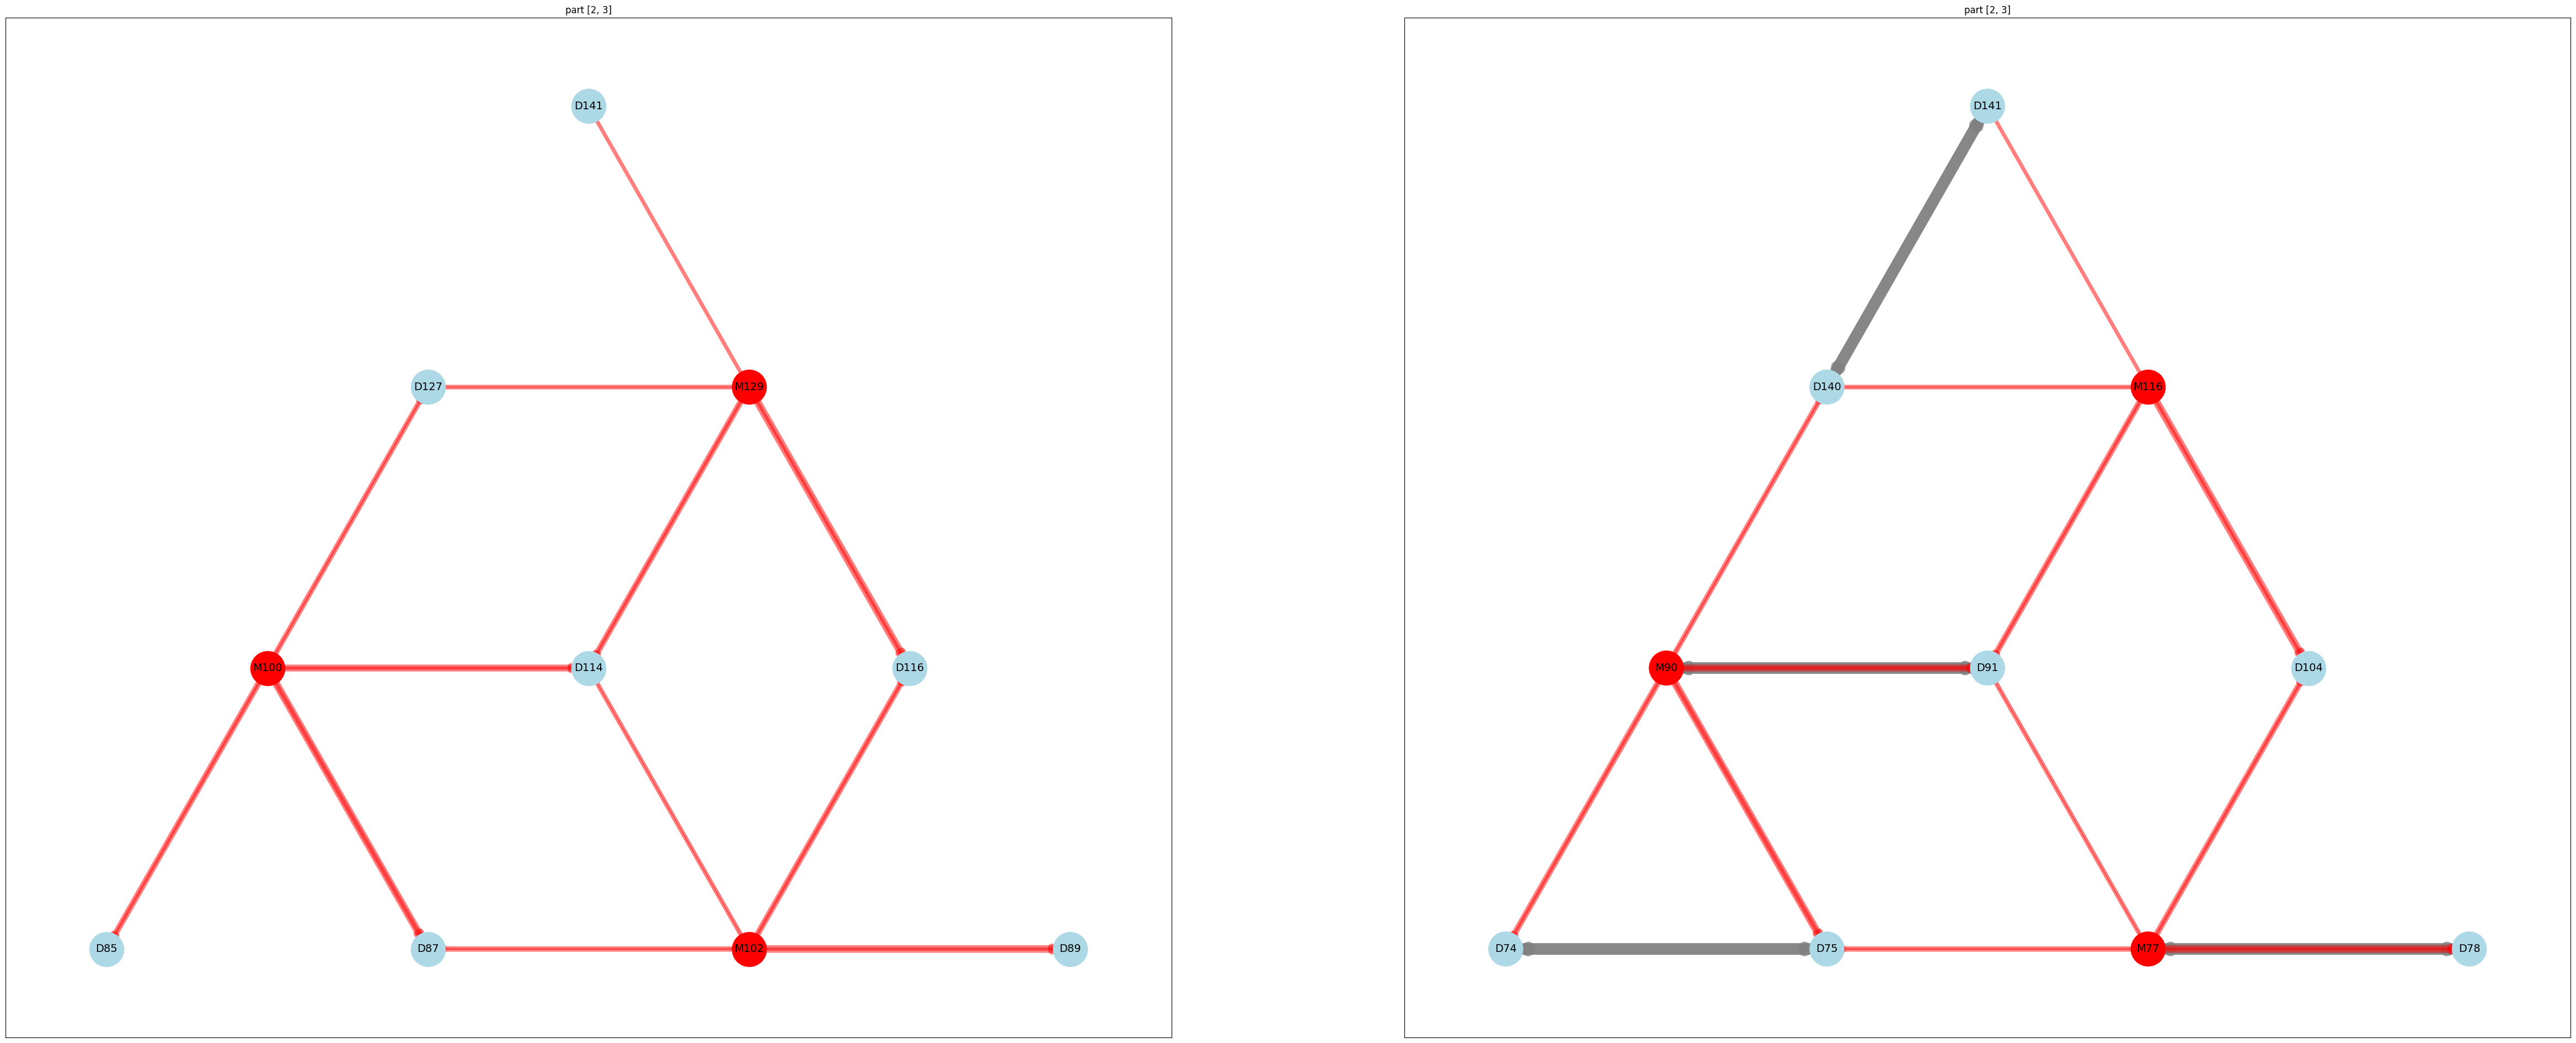

In [12]:
_capacities = [2,3]
rows = 10
cols = 10

label='part'
fig, axs = plt.subplots(1, len(_capacities))
for ax, capacity in zip(axs, _capacities):
    arch1, (instructions,_) = circuit.processCircuitAugmentedGrid(rows=rows, cols=cols, trapCapacity=capacity)
    arch1.ION_SIZE = 2000

    for idx, (ion, pos) in circuit._ionMapping.items():
        ion.set(ion.idx, pos[0], pos[1])

    arch1.refreshGraph()
    edgesDups = []
    edgesPos = []
    ionsInvolved = set()
    score = 0
    for op in instructions:
        if not isinstance(op, TwoQubitMSGate):
            continue
        if not ionsInvolved.isdisjoint(op.ions):
            score+=1
            ionsInvolved=set()
        edgesDups.append((op.ions, score))
        edgesPos.append((op.ionsActedIdxs, score))
        ionsInvolved=ionsInvolved.union(op.ions)
    #print(edgesDups)
    scores = [score for ((ion1,ion2), score) in edgesDups]
    color_from_score = {s: i for i, s in enumerate( sorted(list(set(scores)), reverse=True))}
    #print(color_from_score)
    arch1._manipulationTraps.append(([(ion1.idx, ion2.idx) for ((ion1,ion2), score) in edgesDups], [color_from_score[score] for ((ion1,ion2), score) in edgesDups]))
    arch1.display(fig, ax, showLabels=False, showEdges=False, show_junction=False)
    ax.set_title(f"{label} {_capacities}")


circuit.without_noise().diagram('timeline-svg')

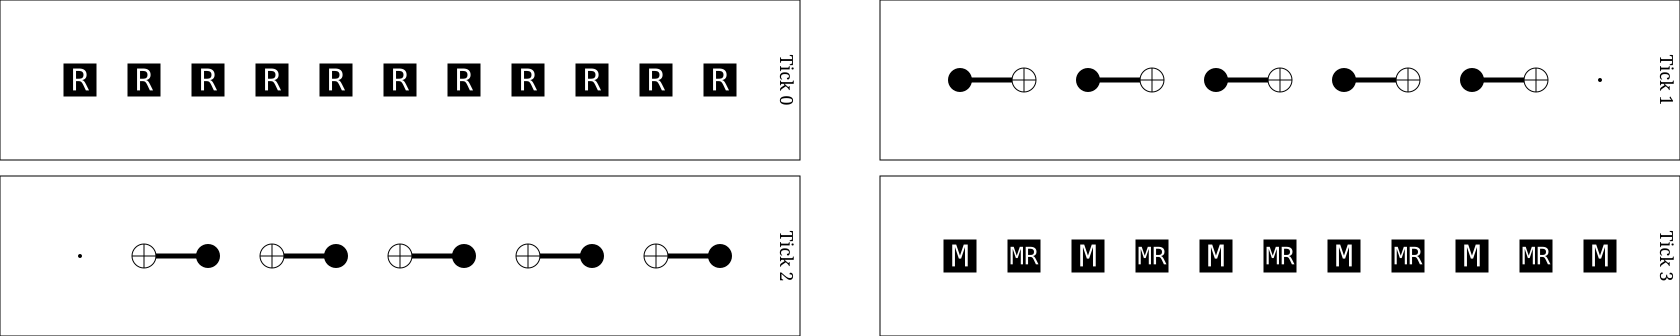

In [8]:
noise=0.01
rounds=1
distance =6
trapCapacity=20
rows=1
cols=20

circuit = QCCDCircuit()
for i in range(2*distance-1):
    circuit+=QCCDCircuit(f"QUBIT_COORDS({i},0) {i}")
circuit += QCCDCircuit.generated(
    "repetition_code:memory",
    rounds=rounds,
    distance=distance,
    after_clifford_depolarization=noise,
    after_reset_flip_probability=noise,
    before_measure_flip_probability=noise,
    before_round_data_depolarization=noise,
)
circuit.without_noise().diagram('timeslice-svg')

total number of routing operations: 0
total number of operations: 77
time for operations: 5400.0
num gate swaps: 0
num splits: 0


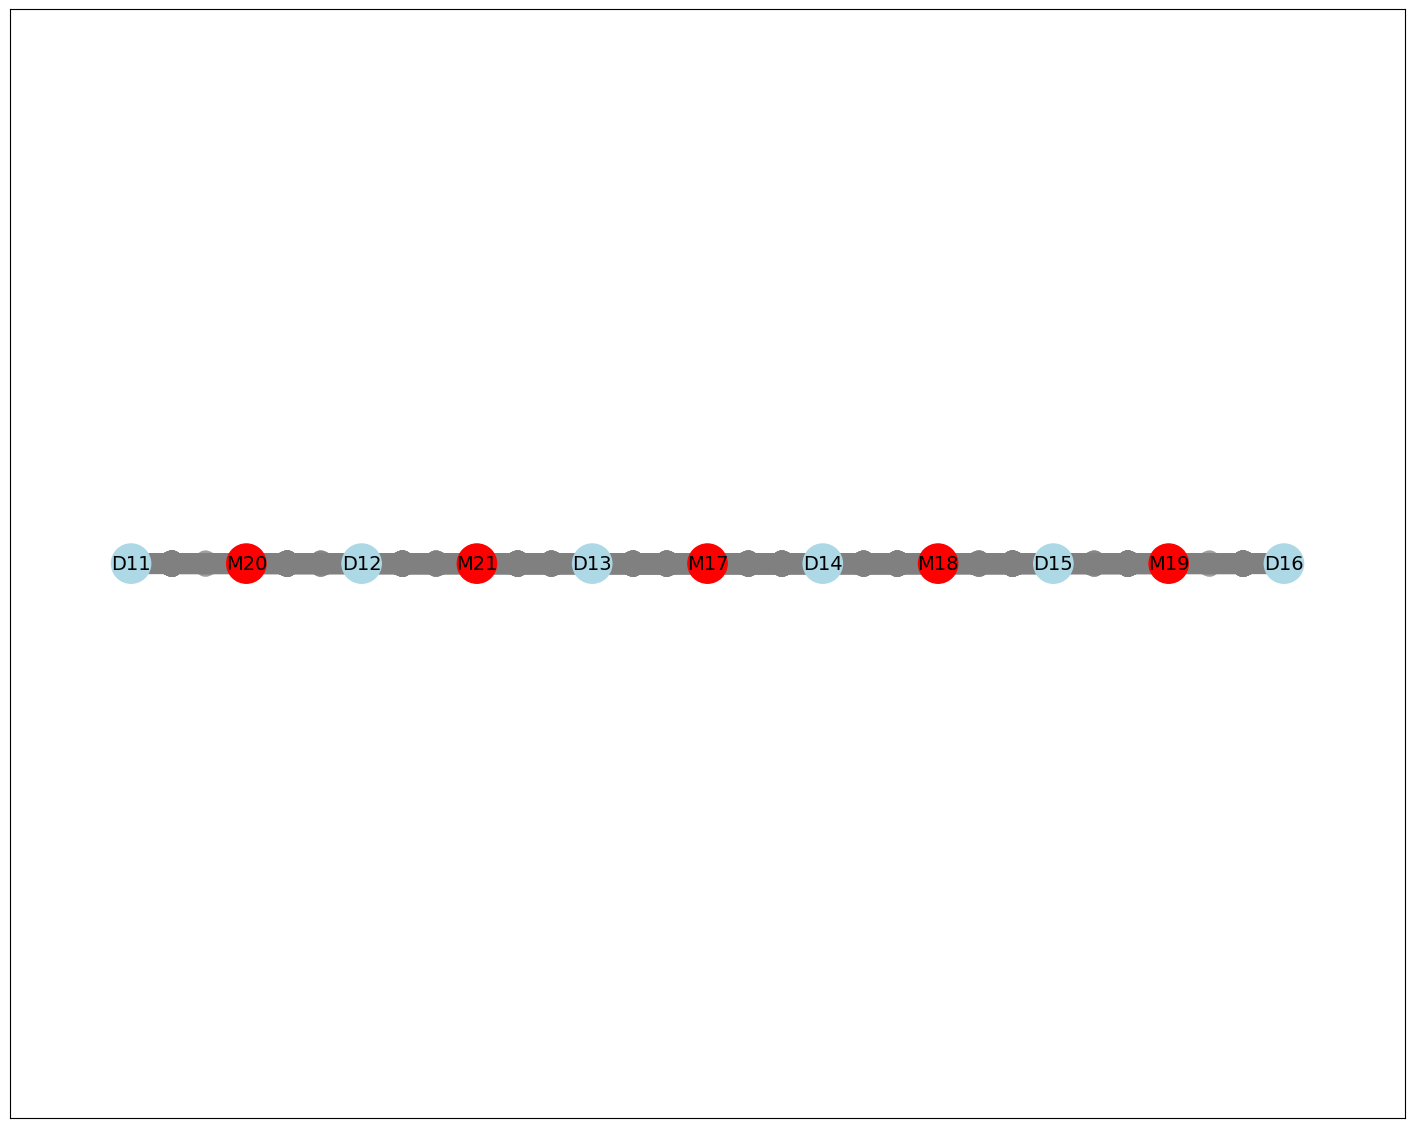

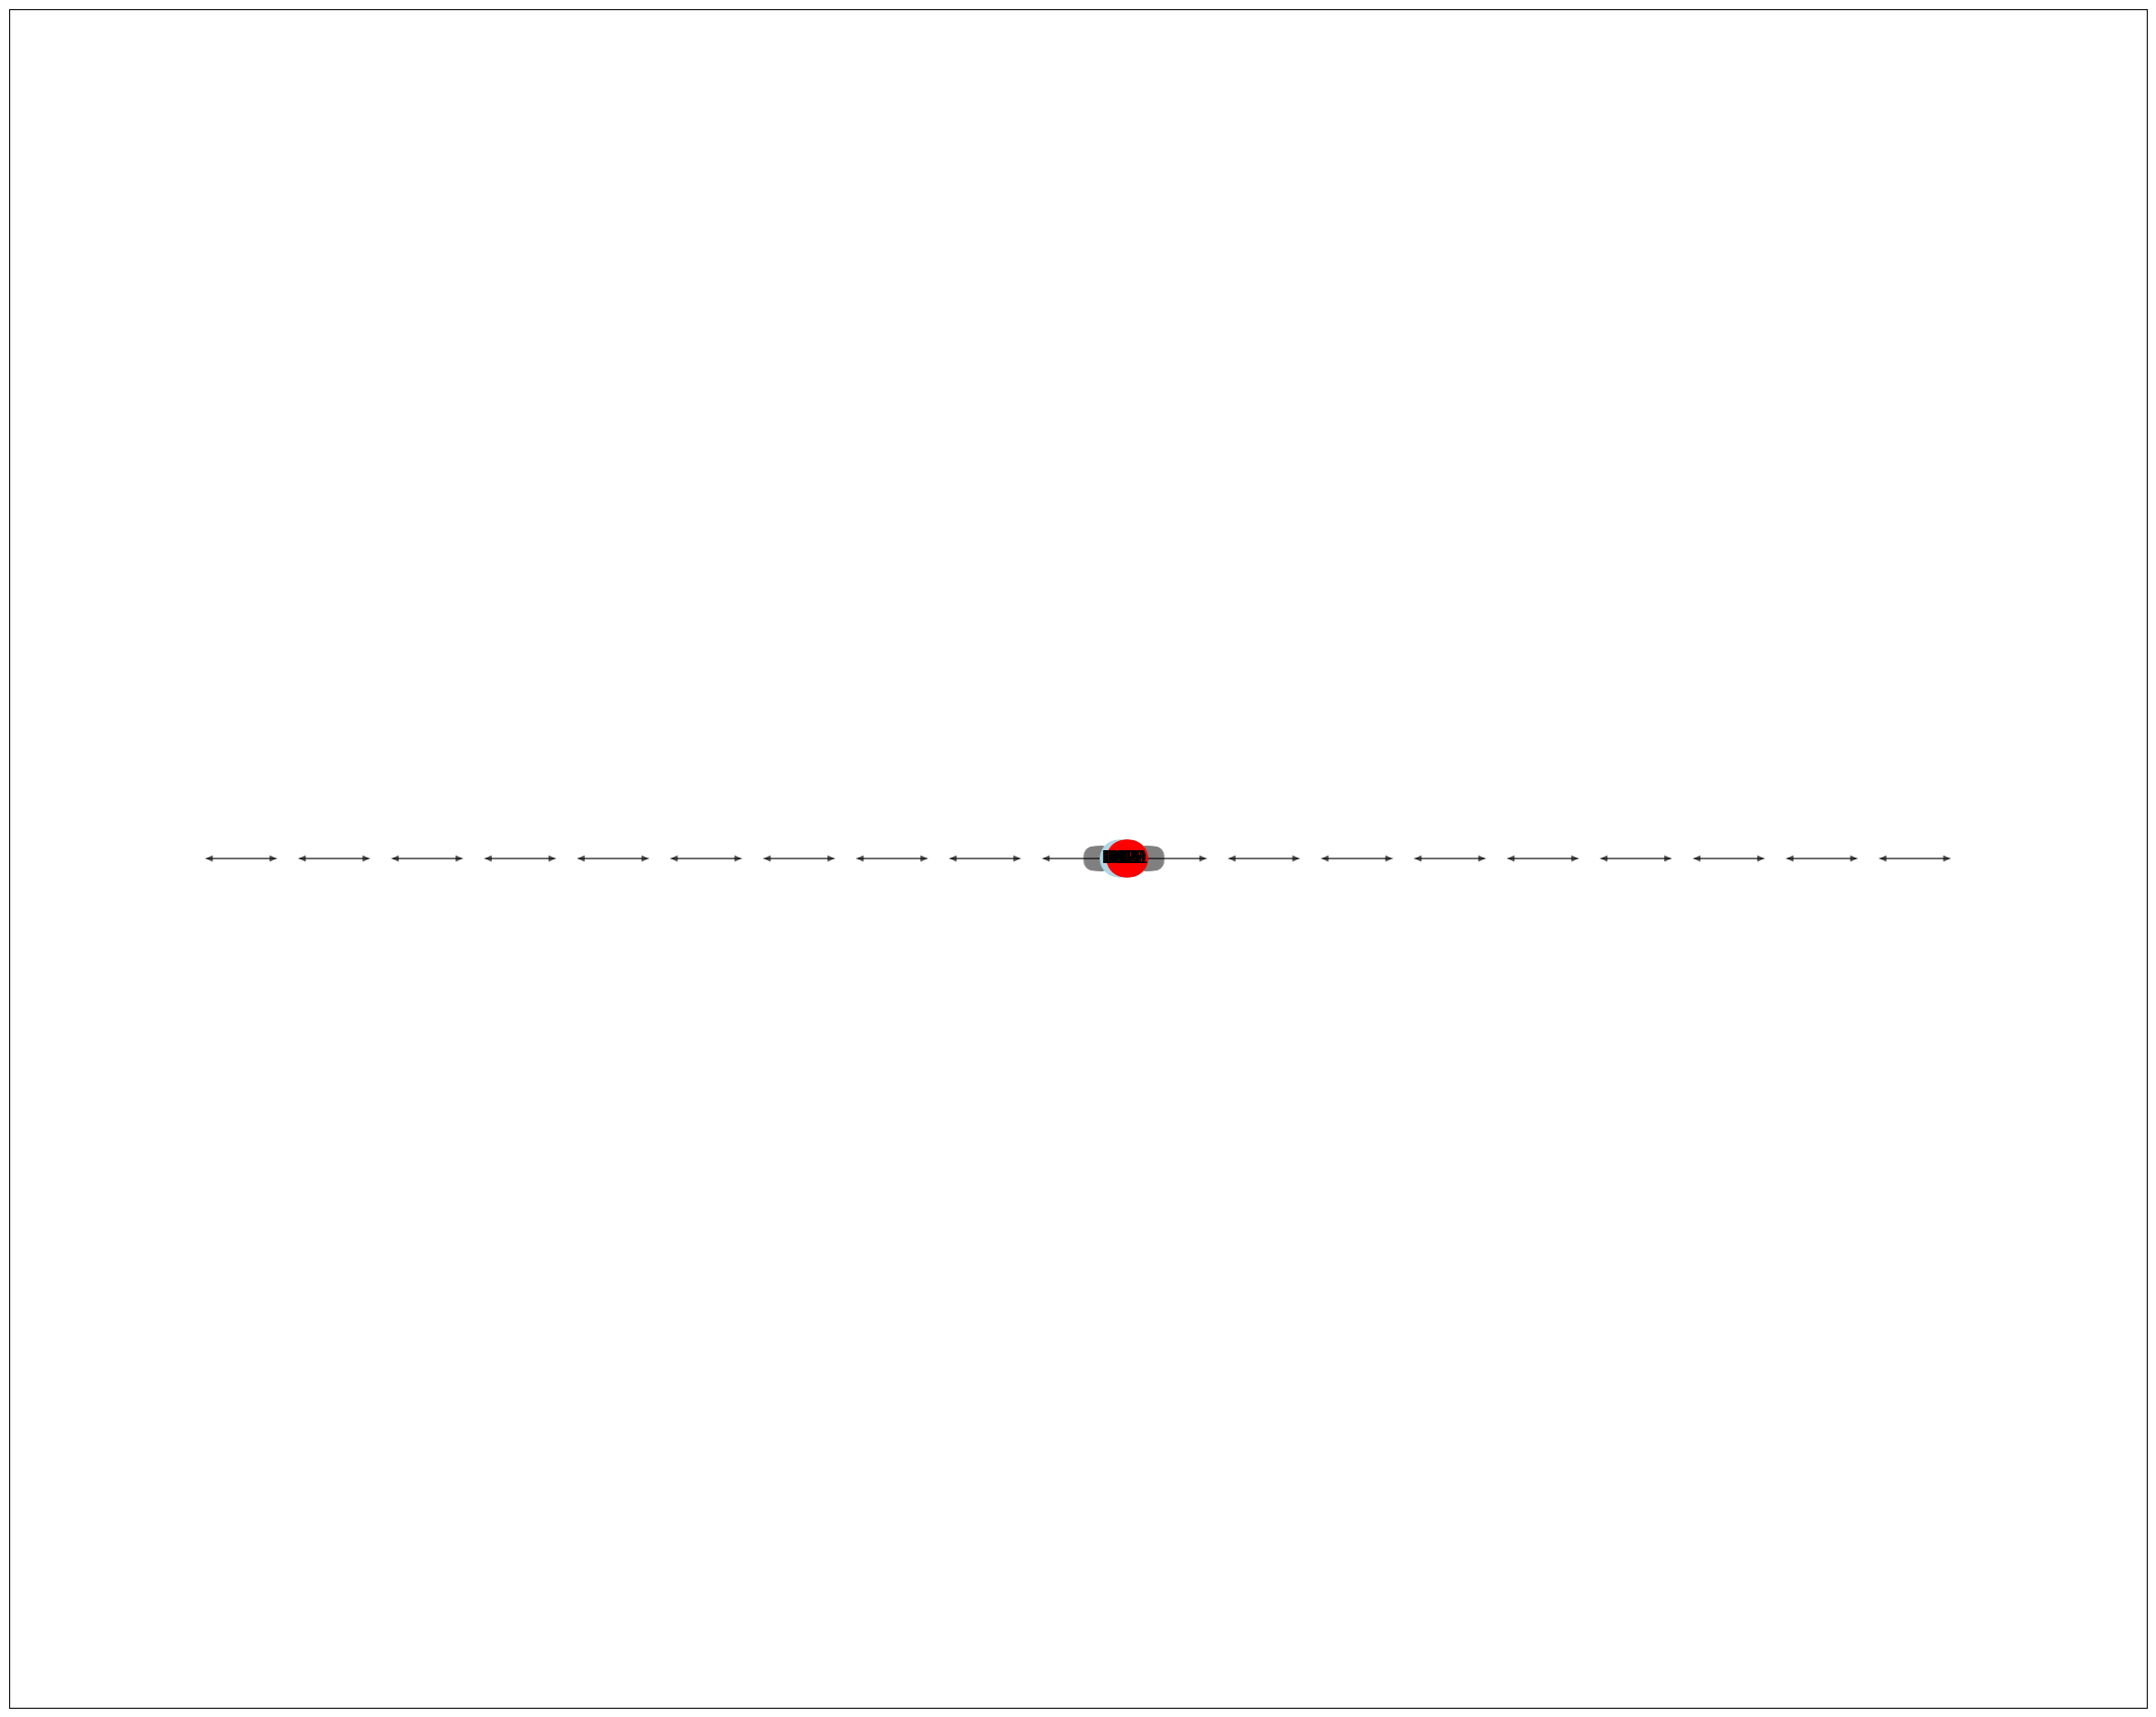

In [9]:
arch, (instructions,_) = circuit.processCircuitAugmentedGrid(rows=rows, cols=cols, trapCapacity=trapCapacity, padding=0)

oldPositions = {}
for idx, (ion, pos) in circuit._ionMapping.items():
    oldPositions[idx] = ion.pos
    ion.set(ion.idx, pos[0], pos[1], parent=ion.parent)

fig,ax =plt.subplots()
arch1 = arch
arch1.refreshGraph()
edgesDups = []
edgesPos = []
ionsInvolved = set()
score = 0
for op in instructions:
    if not isinstance(op, TwoQubitMSGate):
        continue
    if not ionsInvolved.isdisjoint(op.ions):
        score+=1
        ionsInvolved=set()
    edgesDups.append((op.ions, score))
    edgesPos.append((op.ionsActedIdxs, score))
    ionsInvolved=ionsInvolved.union(op.ions)
scores = [score for ((ion1,ion2), score) in edgesDups]
color_from_score = {s: (5+i*i)*0 for i, s in enumerate( sorted(list(set(scores)), reverse=True))}
arch1._manipulationTraps.append(([(ion1.idx, ion2.idx) for ((ion1,ion2), score) in edgesDups], [color_from_score[score] for ((ion1,ion2), score) in edgesDups]))
arch1.display(fig, ax, showLabels=False, showEdges=False, show_junction=False)
fig.set_size_inches(arch.WINDOW_SIZE[0]*0.6, arch.WINDOW_SIZE[1]*0.6)
arch1._manipulationTraps = arch1._manipulationTraps[:-1]
for idx, (ion, pos) in circuit._ionMapping.items():
    ion.set(ion.idx, oldPositions[idx][0], oldPositions[idx][1], parent=ion.parent)


arch.refreshGraph()

fig,ax =plt.subplots()
arch.display(fig, ax, showLabels=False)
fig.set_size_inches(arch.WINDOW_SIZE[0], arch.WINDOW_SIZE[1])

allOps, barriers = ionRouting(arch, instructions, trapCapacity=trapCapacity)
parallelOpsMap = paralleliseOperationsWithBarriers(allOps, barriers)
parallelOps = list(dict(parallelOpsMap).values())


numSplits = sum(1 for instr in allOps if isinstance(instr, Split))
numGateSwaps = sum(1 for instr in allOps if isinstance(instr, GateSwap))

print(f"total number of routing operations: {len(allOps)-len(instructions)}")
print(f"total number of operations: {len(allOps)}")
print(f"time for operations: {max(parallelOpsMap.keys())*1e6}")
print(f"num gate swaps: {numGateSwaps}")
print(f"num splits: {numSplits}")